In [31]:
import numpy as np
import numba as nb
import math
from time import perf_counter
import matplotlib.pyplot as plt
import changepoint_online as cp
from dataclasses import dataclass
from gridcp.scores import MeanCUSUM

from gridcp.old_api import (
    OnlineChangepointDetector,
    make_univariate_mean_change_detector,
    make_univariate_variance_change_detector,
    make_univariate_mean_or_variance_change_detector,
    make_multivariate_mean_change_detector,
    make_multivariate_mean_or_covariance_change_detector,
    make_regression_change_detector,
)
from gridcp.old_api.utils import fastlog
from gridcp.old_api.calibration import draw_samples, mc_max_statistics
from gridcp.old_api import builtins
from gridcp.old_api.builtins import gen_gaussian_regression_obs
# Small change

# Some examples with simulations below

In [2]:
N = 100_000  # stream length
K_calibrate = 10  # number of MC samples for threshold calibration

detector = make_univariate_mean_change_detector()
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)

In [3]:
N = 50  # stream length
K_calibrate = 10000  # number of MC samples for threshold calibration
K = 1000  # number of MC samples for performance evaluation
changepoint_loc = N // 2

## Univariate change-in-mean

In [4]:
p = 1

### Known variance

In [5]:
detector = make_univariate_mean_change_detector()


detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_known_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_known_var)

critical value =  2.9627207432949887


In [6]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 2, "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_mean_change_detector(
        penalty_constant=critical_value_known_var
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 4.337


### Uknown variance

In [7]:
detector = make_univariate_mean_change_detector(mode="unknown_variance")
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_unknown_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_unknown_var)

critical value =  2.435296875811082


In [8]:
changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 2, "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_mean_change_detector(
        penalty_constant=critical_value_unknown_var, mode="unknown_variance"
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 5.754999999999999


### Change in mean or variance

In [9]:
detector = make_univariate_mean_or_variance_change_detector()
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_meanvariance = detector._state["penalty_constant"]
print("critical value = ", critical_value_meanvariance)

critical value =  3.538391071737553


In [10]:
changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 2, "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_mean_or_variance_change_detector(
        penalty_constant=critical_value_meanvariance
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection time: {np.mean(detect_times) - changepoint_loc}")

Average detection time: 10.468000000000004


In [11]:
mus = np.linspace(0, 3, 10)

changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal

dd1 = np.ones((len(mus), K)) * N
dd2 = np.ones((len(mus), K)) * N
dd3 = np.ones((len(mus), K)) * N


for j in range(len(mus)):
    prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
    postchange_kwargs = {"loc": mus[j], "scale": 1, "size": (p,)}
    xs = draw_samples(
        K=K,
        N=N,
        p=p,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_univariate_mean_change_detector(
            penalty_constant=critical_value_known_var
        )
        detector2 = make_univariate_mean_change_detector(
            penalty_constant=critical_value_unknown_var,
            mode="unknown_variance",
        )
        detector3 = make_univariate_mean_or_variance_change_detector(
            penalty_constant=critical_value_meanvariance
        )
        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector3.update(x_new)
            if detector3.alarm:
                dd3[j, k] = i + 1
                break

SystemError: CPUDispatcher(<function update_numba at 0x1384df600>) returned a result with an exception set

In [11]:
print("FA 1:", np.mean(dd1[0] < N))
print("FA 2:", np.mean(dd2[0] < N))
print("FA 3:", np.mean(dd3[0] < N))

FA 1: 0.049
FA 2: 0.054
FA 3: 0.052


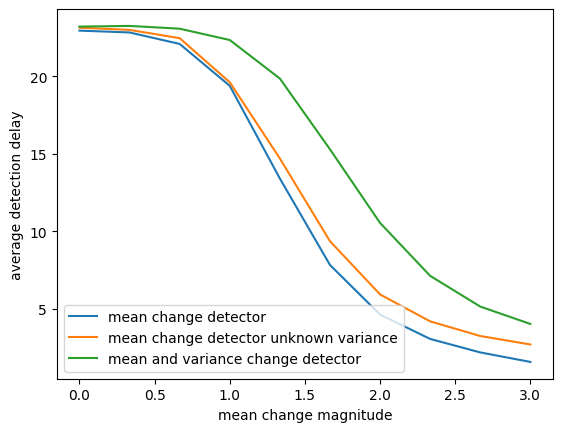

In [12]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc
avg_dd3 = np.mean(dd3, axis=1) - changepoint_loc

plt.plot(mus, avg_dd1, label="mean change detector")
plt.plot(mus, avg_dd2, label="mean change detector unknown variance")
plt.plot(mus, avg_dd3, label="mean and variance change detector")
plt.xlabel("mean change magnitude")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

## Univariate change in variance

### Known mean

In [13]:
detector = make_univariate_variance_change_detector()
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_known_mean = detector._state["penalty_constant"]

In [14]:
changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 0, "scale": 4, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_variance_change_detector(
        penalty_constant=critical_value_known_mean
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection time: {np.mean(detect_times) - changepoint_loc}")

Average detection time: 4.882999999999999


In [15]:
K = 1000
postchangesds = np.linspace(1, 5, 10)


changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal

dd1 = np.ones((len(postchangesds), K)) * N
dd2 = np.ones((len(postchangesds), K)) * N


for j in range(len(postchangesds)):
    prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
    postchange_kwargs = {"loc": 0, "scale": postchangesds[j], "size": (p,)}
    xs = draw_samples(
        K=K,
        N=N,
        p=p,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_univariate_variance_change_detector(
            penalty_constant=critical_value_known_mean
        )
        detector2 = make_univariate_mean_or_variance_change_detector(
            penalty_constant=critical_value_meanvariance
        )
        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break

In [16]:
print("FA 1:", np.mean(dd1[0] < N))
print("FA 2:", np.mean(dd2[0] < N))

FA 1: 0.054
FA 2: 0.052


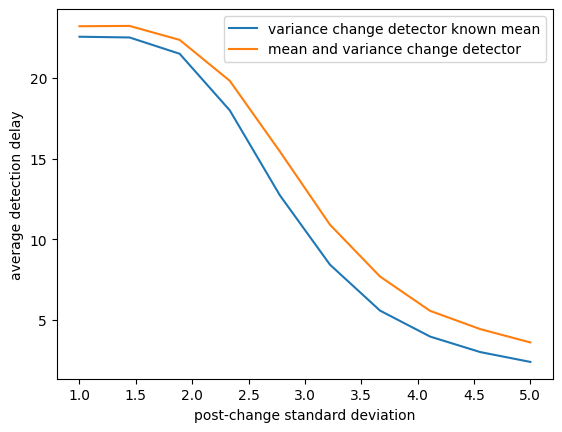

In [17]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc

plt.plot(postchangesds, avg_dd1, label="variance change detector known mean")
plt.plot(postchangesds, avg_dd2, label="mean and variance change detector")
plt.xlabel("post-change standard deviation")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

## Multivariate change in mean

In [18]:
p = 10
N = 50  # stream length
K_calibrate = 10000  # number of MC samples for threshold calibration
K = 1000  # number of MC samples for performance evaluation
changepoint_loc = N // 2

### Known variance (identity)

In [19]:
detector = make_multivariate_mean_change_detector(p=p)
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0, "scale": 1, "size": (p,)},
)
critical_value_multivariate_known_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_multivariate_known_var)

critical value =  3.2426766089345445


In [20]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 3 / math.sqrt(p), "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_multivariate_mean_change_detector(
        p=p, penalty_constant=critical_value_multivariate_known_var
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 2.8810000000000002


### Uknown variance

In [21]:
detector = make_multivariate_mean_change_detector(p=p, mode="unknown_variance")
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0, "scale": 1, "size": (p,)},
)
critical_value_multivariate_unknown_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_multivariate_unknown_var)

critical value =  2.5163534066256585


In [22]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 3 / math.sqrt(p), "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_multivariate_mean_change_detector(
        p=p,
        penalty_constant=critical_value_multivariate_unknown_var,
        mode="unknown_variance",
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 8.354999999999997


### Change in mean or variance

In [23]:
detector = make_multivariate_mean_or_covariance_change_detector(p=p)
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0, "scale": 1, "size": (p,)},
)
critical_value_multivariate_meanvariance = detector._state["penalty_constant"]
print("critical value = ", critical_value_meanvariance)

critical value =  3.538391071737553


In [24]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 3 / math.sqrt(p), "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_multivariate_mean_or_covariance_change_detector(
        p=p, penalty_constant=critical_value_multivariate_meanvariance
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection time: {np.mean(detect_times) - changepoint_loc}")

Average detection time: 21.247999999999998


In [25]:
phis = np.linspace(0, 6, 10)

changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal

dd1 = np.ones((len(phis), K)) * N
dd2 = np.ones((len(phis), K)) * N
dd3 = np.ones((len(phis), K)) * N


for j in range(len(phis)):
    prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
    postchange_kwargs = {"loc": phis[j] / math.sqrt(p), "scale": 1, "size": (p,)}
    xs = draw_samples(
        K=K,
        N=N,
        p=p,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_multivariate_mean_change_detector(
            p=p, penalty_constant=critical_value_multivariate_known_var
        )
        detector2 = make_multivariate_mean_change_detector(
            p=p,
            penalty_constant=critical_value_multivariate_unknown_var,
            mode="unknown_variance",
        )
        detector3 = make_multivariate_mean_or_covariance_change_detector(
            p=p, penalty_constant=critical_value_multivariate_meanvariance
        )
        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector3.update(x_new)
            if detector3.alarm:
                dd3[j, k] = i + 1
                break

In [26]:
print("FA 1:", np.mean(dd1[0] < N))
print("FA 2:", np.mean(dd2[0] < N))
print("FA 3:", np.mean(dd3[0] < N))

FA 1: 0.055
FA 2: 0.039
FA 3: 0.052


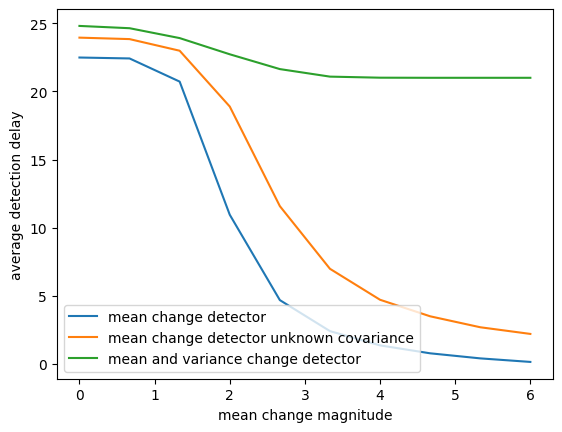

In [27]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc
avg_dd3 = np.mean(dd3, axis=1) - changepoint_loc

plt.plot(phis, avg_dd1, label="mean change detector")
plt.plot(phis, avg_dd2, label="mean change detector unknown covariance")
plt.plot(phis, avg_dd3, label="mean and variance change detector")
plt.xlabel("mean change magnitude")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

# Change in regression coefficients

### McScan

In [6]:
N = 200
q = 10
K_calibrate = 1000
K = 1000
beta0 = np.random.normal(loc=0, scale=1, size=(q,))

detector = make_regression_change_detector(q=q)
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=gen_gaussian_regression_obs,
    null_kwargs={"beta0": beta0},
)
critical_value_reg = detector._state["penalty_constant"]
print("critical value = ", critical_value_reg)

critical value =  11.955805843341558


### Direct

In [7]:
N = 200
q = 10
K_calibrate = 1000
K = 1000
beta0 = np.random.normal(loc=0, scale=1, size=(q,))

detector = make_regression_change_detector(q=q, mode="direct")
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=gen_gaussian_regression_obs,
    null_kwargs={"beta0": beta0},
)
critical_value_reg_direct = detector._state["penalty_constant"]
print("critical value = ", critical_value_reg_direct)

critical value =  46.80811930977104


In [10]:
rhos = np.linspace(0, 30, 10)
s = q
K = 100
changepoint_loc = N // 2
prechange_dist = gen_gaussian_regression_obs
postchange_dist = gen_gaussian_regression_obs

dd1 = np.ones((len(rhos), K)) * N
dd2 = np.ones((len(rhos), K)) * N


for j in range(len(rhos)):
    prechange_kwargs = {"beta0": beta0}
    postchange_kwargs = {
        "beta0": beta0,
        "add_perturbation": True,
        "rho": rhos[j],
        "s": s,
    }
    xs = draw_samples(
        K=K,
        N=N,
        p=q + 1,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_regression_change_detector(
            q=q, penalty_constant=critical_value_reg
        )
        detector2 = make_regression_change_detector(
            q=q, penalty_constant=critical_value_reg_direct, mode="direct"
        )

        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break

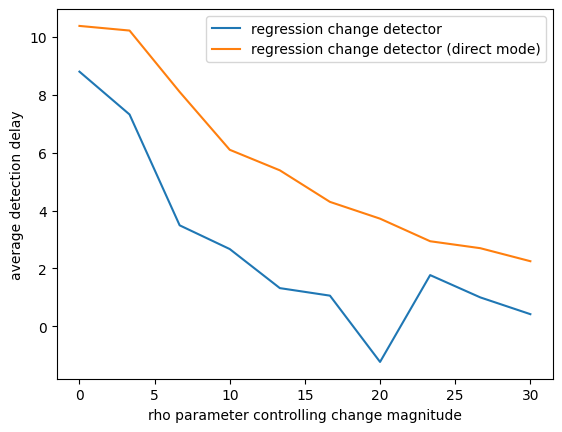

In [11]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc


plt.plot(rhos, avg_dd1, label="regression change detector")
plt.plot(rhos, avg_dd2, label="regression change detector (direct mode)")
plt.xlabel("rho parameter controlling change magnitude")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

### Make your own detector

In [ ]:
@nb.njit(cache=True)
def change_univariate_simple_f(sum_pre, sum_post, pos, t, q=2):
    g = t - pos
    n1 = pos
    n2 = g

    mean_pre = sum_pre / n1
    mean_post = sum_post / n2
    out_stat = (mean_pre - mean_post) ** q
    return np.sum(out_stat)


@nb.njit(cache=True)
def change_univariate_simple_h(x):
    return x


@nb.njit(cache=False)
def _scalar_max_ll(ki, n_i):
    if ki <= 0 or ki >= n_i:
        return 0.0
    p_hat = ki / n_i
    return ki * np.log(p_hat) + (n_i - ki) * np.log1p(-p_hat)


@nb.njit(cache=True)
def bernoulli_max_ll(k, n):
    # k successes in n trials; returns max log-likelihood under Bernoulli
    # (i.e. with p = k/n). For k=0 or k=n this is 0. Supports scalar k
    # or 1D arrays of ks.

    out = np.empty(k.shape, dtype=np.float64)
    for i in range(k.shape[0]):
        out[i] = _scalar_max_ll(k[i], n)
    return out


@nb.njit(cache=True)
def change_univariate_simple_penalty(pos, t, p):
    logg = fastlog(t)
    logg = logg + math.sqrt(logg)
    return logg



@nb.njit(cache=True)
def bernoulli_max_ll(k, n):
    # k successes in n trials; returns max log-likelihood under Bernoulli
    # (i.e. with p = k/n). For k=0 or k=n this is 0. Supports scalar k
    # or 1D arrays of ks.

    out = np.empty(k.shape, dtype=np.float64)
    for i in range(k.shape[0]):
        out[i] = _scalar_max_ll(k[i], n)
    return out

@nb.njit(cache=False)
def change_bernoulli_f(sum_pre, sum_post, pos, t):
    # Use the exact Bernoulli maximum log-likelihood values.
    # For k=0 or k=n, the max log-likelihood is 0 (log(1)=0), so this is a
    # well-defined finite value and avoids any log(0) issues.

    g = t - pos
    if pos <= 0 or g <= 0:
        return 0.0

    ll_post = bernoulli_max_ll(sum_post, g)
    ll_pre = bernoulli_max_ll(sum_pre, pos)
    ll_tot = bernoulli_max_ll(sum_pre + sum_post, t)
    out = 2.0 * (ll_post + ll_pre - ll_tot)
    # If `out` is scalar, return directly; if it's array, sum over entries.
    return np.sum(out)


@nb.njit(cache=False)
def change_bernoulli_h(x):
    grid = np.arange(-5, 5, 0.05)
    return np.array([x[0] <= p for p in grid], dtype=np.float64)


In [ ]:

"""
detector = OnlineChangepointDetector(
    p=1,
    f=change_bernoulli_f,
    h=change_bernoulli_h,
    penalty=change_bernoulli_penalty,
    penalty_constant=10,
)

N = 100000  # stream length
K_calibrate = 10  # number of MC samples for threshold calibration
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=np.random.normal,
)
critical_value_known_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_known_var)
"""

@nb.njit(cache=False)
def change_bernoulli_penalty(t):
    """Return the penalty used to scale the Bernoulli change score.

    Parameters
    ----------
    t : int
        Number of observations seen so far.

    Returns
    -------
    int
        Constant penalty factor. The current notebook implementation uses
        a fixed penalty equal to `1`, so the raw likelihood-ratio score is
        left unchanged.
    """
    return 1


@nb.njit(cache=False)
def _scalar_max_ll(ki, n_i):
    """Evaluate the Bernoulli maximized log-likelihood for one count.

    This computes the log-likelihood at the MLE $\hat p = k_i / n_i$ for
    a Bernoulli sample with `ki` successes out of `n_i` trials. The boundary
    cases `ki = 0` and `ki = n_i` are handled explicitly and return `0.0`,
    which matches the limiting value of the maximized log-likelihood.

    Parameters
    ----------
    ki : int | float
        Number of successes.
    n_i : int
        Number of Bernoulli trials.

    Returns
    -------
    float
        Maximized Bernoulli log-likelihood contribution for the sample.
    """
    if ki <= 0 or ki >= n_i:
        return 0.0
    p_hat = ki / n_i
    return ki * np.log(p_hat) + (n_i - ki) * np.log1p(-p_hat)


@nb.njit(cache=True)
def bernoulli_max_ll(k, n):
    """Vectorize `_scalar_max_ll` over a grid of Bernoulli counts.

    Parameters
    ----------
    k : np.ndarray
        One-dimensional array of success counts, typically one entry per
        grid point in the NPFOCuS discretization.
    n : int
        Number of trials associated with each entry in `k`.

    Returns
    -------
    np.ndarray
        Array with the same shape as `k`, where each entry contains the
        maximized Bernoulli log-likelihood for that count.
    """

    out = np.empty(k.shape, dtype=np.float64)
    for i in range(k.shape[0]):
        out[i] = _scalar_max_ll(k[i], n)
    return out


@nb.njit(cache=False)
def change_bernoulli_score(
    total_sum: np.ndarray,
    before_sums: np.ndarray,
    total_samples: int,
    before_samples: np.ndarray,
):
    """Compute Bernoulli likelihood-ratio scores for all active candidates.

    Each candidate changepoint splits the current stream into a pre-change
    and a post-change segment. For every candidate, this function evaluates
    the generalized likelihood-ratio statistic across the full evaluation
    grid and returns one aggregated score per candidate.

    Parameters
    ----------
    total_sum : np.ndarray
        Total number of indicators below each grid point over the full
        stream observed so far.
    before_sums : np.ndarray
        Matrix whose rows contain the corresponding cumulative counts for
        each active candidate changepoint.
    total_samples : int
        Total number of observations in the current stream prefix.
    before_samples : np.ndarray
        Number of observations assigned to the pre-change segment for each
        active candidate.

    Returns
    -------
    np.ndarray
        One score per active candidate changepoint.
    """
    n_candidates = before_sums.shape[0]
    scores = np.zeros(n_candidates, dtype=np.float64)
    if total_samples <= 0:
        return scores

    ll_tot = bernoulli_max_ll(total_sum, total_samples)

    for j in range(n_candidates):
        n_pre = before_samples[j]
        n_post = total_samples - n_pre
        if n_pre <= 0 or n_post <= 0:
            continue

        sum_pre = before_sums[j]
        sum_post = total_sum - sum_pre
        ll_pre = bernoulli_max_ll(sum_pre, n_pre)
        ll_post = bernoulli_max_ll(sum_post, n_post)
        scores[j] = np.sum(2.0 * (ll_post + ll_pre - ll_tot))

    return scores


@dataclass(slots=True)
class NPFOCuSState:
    """Running state for the notebook NPFOCuS score.

    Parameters
    ----------
    n_samples : int, default=0
        Number of observations incorporated so far.
    n_smaller : np.ndarray | None, default=None
        Vector of length `n_grid` where entry `j` stores how many observed
        samples are less than or equal to the `j`th grid point.
    """

    n_samples: int = 0
    n_smaller: np.ndarray = None


@dataclass(frozen=True, slots=True)
class NPFOCuS:
    """Nonparametric FOCuS score for univariate changepoint detection.

    The score discretizes the sample space using `grid` and tracks, at each
    grid point, how many observations fall below that value. Candidate
    changepoints are then compared with Bernoulli likelihood-ratio scores
    computed on those indicator processes.

    Parameters
    ----------
    grid : np.ndarray | None, default=None
        One-dimensional evaluation grid used to build the indicator process
        underlying the NPFOCuS score.
    """

    grid: np.ndarray = None

    def init_state(self) -> NPFOCuSState:
        """Create an empty NPFOCuS state for the configured grid.

        Returns
        -------
        NPFOCuSState
            State with zero observations and zero counts at every grid point.
        """
        return NPFOCuSState(
            n_samples=0,
            n_smaller=np.zeros(len(self.grid), dtype=np.int64),
        )

    def update(self, state: NPFOCuSState, x_new: float) -> NPFOCuSState:
        """Update the NPFOCuS state with one new observation.

        Parameters
        ----------
        state : NPFOCuSState
            Current running state.
        x_new : float
            New scalar observation.

        Returns
        -------
        NPFOCuSState
            Updated state after incrementing the sample count and the grid
            indicators corresponding to `x_new`.
        """
        n_samples = state.n_samples + 1
        n_smaller = state.n_smaller.copy()
        n_smaller += (np.asarray(x_new).reshape(-1)[0] <= self.grid).astype(np.int64)
        return NPFOCuSState(n_samples=n_samples, n_smaller=n_smaller)

    def compute_penalised_scores(
        self, state: NPFOCuSState, grid_states: list[NPFOCuSState]
    ) -> np.ndarray:
        """Compute penalized scores for all active candidate changepoints.

        Parameters
        ----------
        state : NPFOCuSState
            State for the full stream observed so far.
        grid_states : list[NPFOCuSState]
            States associated with the active candidate changepoints.

        Returns
        -------
        np.ndarray
            Penalized score for each active candidate changepoint.

        Raises
        ------
        ValueError
            If `grid_states` is empty.
        """
        if len(grid_states) == 0:
            raise ValueError("grid_states is empty.")

        grid_sums = np.stack([gs.n_smaller for gs in grid_states])
        grid_n_samples = np.array([gs.n_samples for gs in grid_states], dtype=np.int64)
        scores = change_bernoulli_score(
            total_sum=state.n_smaller,
            before_sums=grid_sums,
            total_samples=state.n_samples,
            before_samples=grid_n_samples,
        )

        penalty = change_bernoulli_penalty(state.n_samples)
        return scores / penalty

Calibrated threshold: 761.9592
Alarm triggered at time: 502
True changepoint: 501
Detection delay: 1
Peak NPFOCuS score occurs at time: 1000
Peak NPFOCuS score: 28520.2673


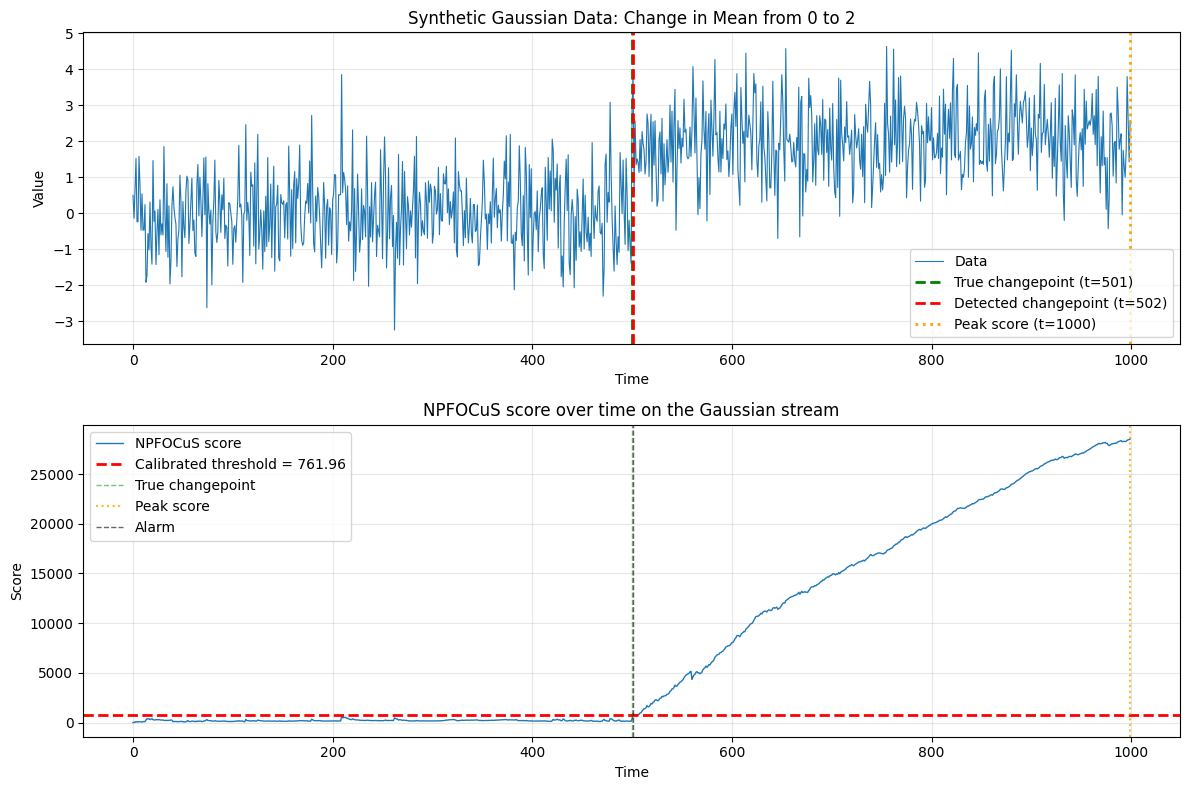


NPFOCuS results on Gaussian change-in-mean data:
  Stream length: 1000
  Change magnitude: 2.0
  Grid size: 201
  Calibration paths: 200
  False alarm probability: 0.05


In [19]:
from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold


def normal_sampler(loc=0.0, scale=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return rng.normal(loc=loc, scale=scale)


def run_online_grid_detector(data, detector):
    state = detector.init_state()
    outputs = []

    for x in np.asarray(data):
        state, output = detector.update(state, x)
        outputs.append(output)

    return outputs


np.random.seed(42)
N_test = 1000
changepoint = N_test // 2

X_gaussian = np.concatenate(
    [
        np.random.normal(0, 1, changepoint),
        np.random.normal(2, 1, N_test - changepoint),
    ]
)

false_alarm_probability = 0.05
n_paths_calibrate = 200  # Keep calibration modest for notebook runtime.
score_model = NPFOCuS(grid=np.linspace(-5, 5, 201))

npfocus_threshold = calibrate_threshold(
    score=score_model,
    false_alarm_probability=false_alarm_probability,
    stream_len=N_test,
    n_paths=n_paths_calibrate,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=123,
    n_features=1,
    parallel=False,
)

detector_npfocus = GridDetector(score=score_model, threshold=npfocus_threshold)
outputs = run_online_grid_detector(X_gaussian, detector_npfocus)

npfocus_scores = np.array([output["max_score"] for output in outputs], dtype=np.float64)
alarm_times = [output["num_samples"] for output in outputs if output["alarm"]]
alarm_time_npfocus = alarm_times[0] if alarm_times else None
peak_time_npfocus = int(np.argmax(npfocus_scores)) + 1

print(f"Calibrated threshold: {npfocus_threshold:.4f}")
if alarm_time_npfocus is not None:
    detection_delay_npfocus = alarm_time_npfocus - changepoint - 1
    print(f"Alarm triggered at time: {alarm_time_npfocus}")
    print(f"True changepoint: {changepoint + 1}")
    print(f"Detection delay: {detection_delay_npfocus}")
else:
    detection_delay_npfocus = None
    print("No alarm triggered")

print(f"Peak NPFOCuS score occurs at time: {peak_time_npfocus}")
print(f"Peak NPFOCuS score: {np.max(npfocus_scores):.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(X_gaussian, linewidth=0.8, label="Data")
ax1.axvline(
    changepoint,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"True changepoint (t={changepoint + 1})",
)
if alarm_time_npfocus is not None:
    ax1.axvline(
        alarm_time_npfocus - 1,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Detected changepoint (t={alarm_time_npfocus})",
    )
ax1.axvline(
    peak_time_npfocus - 1,
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"Peak score (t={peak_time_npfocus})",
)
ax1.set_xlabel("Time")
ax1.set_ylabel("Value")
ax1.set_title("Synthetic Gaussian Data: Change in Mean from 0 to 2")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(npfocus_scores, linewidth=1, label="NPFOCuS score")
ax2.axhline(
    npfocus_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Calibrated threshold = {npfocus_threshold:.2f}",
)
ax2.axvline(
    changepoint,
    color="green",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="True changepoint",
)
ax2.axvline(
    peak_time_npfocus - 1,
    color="orange",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    label="Peak score",
)
if alarm_time_npfocus is not None:
    ax2.axvline(
        alarm_time_npfocus - 1,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label="Alarm",
    )
ax2.set_xlabel("Time")
ax2.set_ylabel("Score")
ax2.set_title("NPFOCuS score over time on the Gaussian stream")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNPFOCuS results on Gaussian change-in-mean data:")
print(f"  Stream length: {N_test}")
print("  Change magnitude: 2.0")
print(f"  Grid size: {score_model.grid.size}")
print(f"  Calibration paths: {n_paths_calibrate}")
print(f"  False alarm probability: {false_alarm_probability}")

## Compare notebook NPFoCUS to changepoint_online.NPFocus

This comparison uses a shared 25-point grid for both detectors. The threshold for each method is calibrated in the same way as above: simulate null paths, record the pathwise maximum score, and take the empirical $(1-\alpha)$ quantile.

25-point-grid comparison: notebook NPFoCUS vs changepoint_online.NPFocus

Grid size: 25
Notebook threshold: 94.3688
Package threshold:  74.7835
Notebook alarm time: 502
Package alarm time:  507
Notebook detection delay: 1
Package detection delay:  6
Notebook peak time: 1000
Package peak time:  1000
Package changepoint estimate at first alarm: 500
Notebook calibration time: 5.961 s
Package calibration time:  35.181 s
Notebook run time: 0.028 s
Package run time:  0.185 s


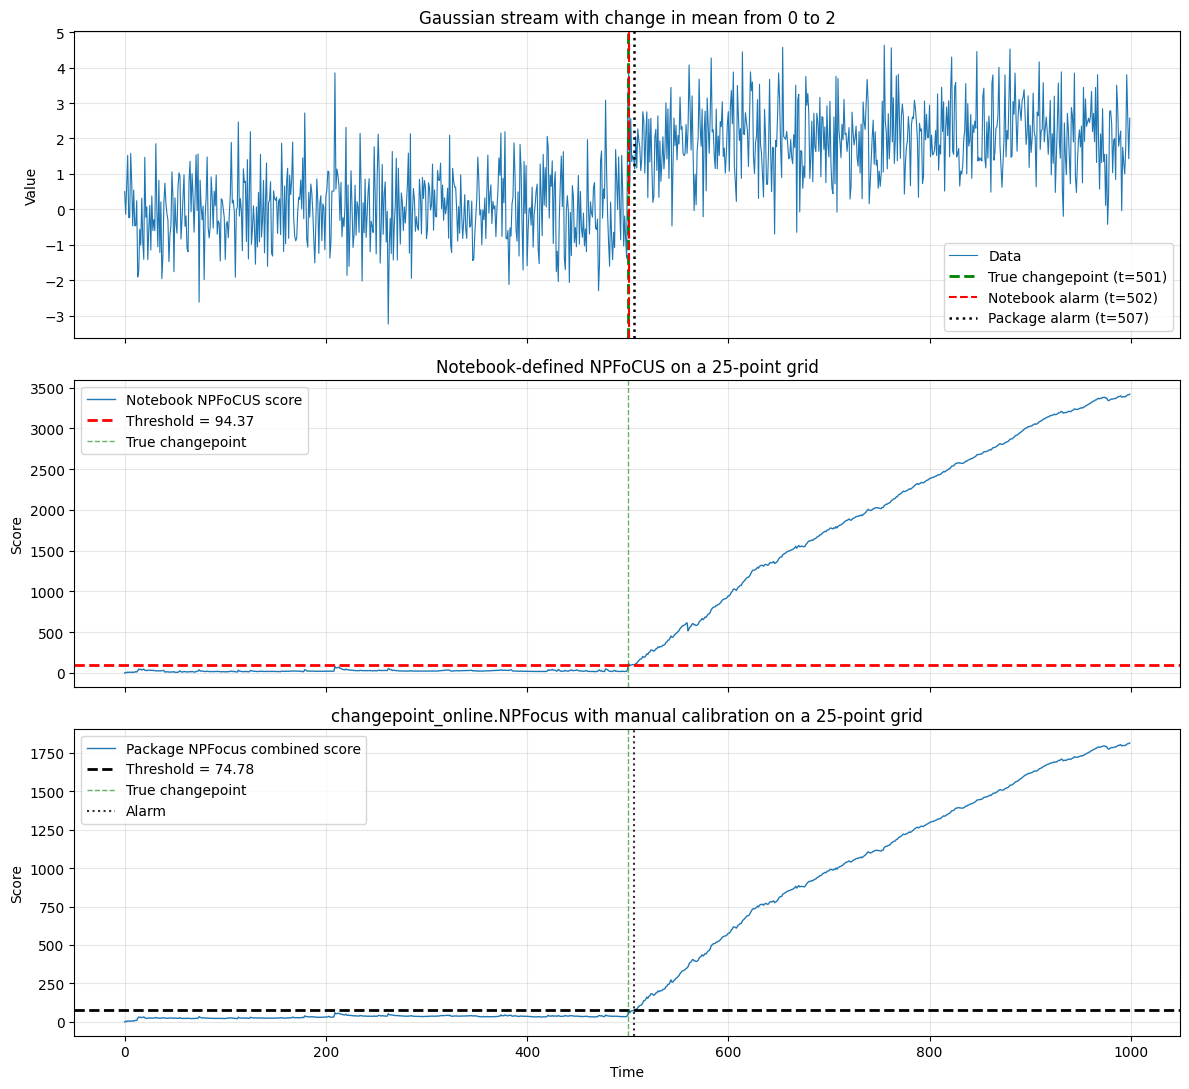

In [26]:
from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold, draw_samples as draw_grid_samples


def calibrate_package_npfocus_threshold(
    quantiles,
    *,
    false_alarm_probability,
    n_paths,
    stream_len,
    pre_sampler,
    pre_kwargs=None,
    rng=None,
    side="both",
):
    if pre_kwargs is None:
        pre_kwargs = {}

    null_paths = draw_grid_samples(
        n_paths=n_paths,
        stream_len=stream_len,
        n_features=1,
        pre_sampler=pre_sampler,
        pre_kwargs=pre_kwargs,
        rng=rng,
    )

    max_scores = np.zeros(n_paths, dtype=np.float64)
    for path_idx in range(n_paths):
        detector = cp.NPFocus(quantiles=quantiles, side=side)
        path_max_score = 0.0
        for x in null_paths[path_idx, :, 0]:
            detector.update(float(x))
            score = float(np.sum(detector.statistic()))
            if score > path_max_score:
                path_max_score = score
        max_scores[path_idx] = path_max_score

    threshold = float(np.quantile(max_scores, 1.0 - false_alarm_probability))
    return threshold, max_scores


def run_package_npfocus(data, detector, threshold):
    outputs = []
    first_alarm_info = None

    for t, x in enumerate(np.asarray(data), start=1):
        x_scalar = float(np.asarray(x).reshape(-1)[0])
        detector.update(x_scalar)

        component_scores = np.asarray(detector.statistic(), dtype=np.float64)
        total_score = float(np.sum(component_scores))
        alarm = total_score > threshold

        if alarm and first_alarm_info is None:
            first_alarm_info = detector.changepoint()

        outputs.append(
            {
                "num_samples": t,
                "score": total_score,
                "alarm": alarm,
            }
        )

    return outputs, first_alarm_info


comparison_grid = np.linspace(-5, 5, 25)
comparison_score_model = NPFOCuS(grid=comparison_grid)

start_time = perf_counter()
comparison_npfocus_threshold = calibrate_threshold(
    score=comparison_score_model,
    false_alarm_probability=false_alarm_probability,
    stream_len=N_test,
    n_paths=n_paths_calibrate,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=123,
    n_features=1,
    parallel=False,
)
comparison_npfocus_calibration_time = perf_counter() - start_time

comparison_detector_npfocus = GridDetector(
    score=comparison_score_model,
    threshold=comparison_npfocus_threshold,
)
start_time = perf_counter()
comparison_outputs = run_online_grid_detector(X_gaussian, comparison_detector_npfocus)
comparison_npfocus_run_time = perf_counter() - start_time

comparison_npfocus_scores = np.array(
    [output["max_score"] for output in comparison_outputs],
    dtype=np.float64,
)
comparison_alarm_times = [
    output["num_samples"] for output in comparison_outputs if output["alarm"]
]
comparison_alarm_time = (
    comparison_alarm_times[0] if comparison_alarm_times else None
)
comparison_peak_time = int(np.argmax(comparison_npfocus_scores)) + 1
comparison_detection_delay = (
    comparison_alarm_time - changepoint - 1
    if comparison_alarm_time is not None
    else None
)

package_quantiles = comparison_grid.tolist()
start_time = perf_counter()
package_threshold, package_null_max_scores = calibrate_package_npfocus_threshold(
    quantiles=package_quantiles,
    false_alarm_probability=false_alarm_probability,
    n_paths=n_paths_calibrate,
    stream_len=N_test,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=123,
)
package_calibration_time = perf_counter() - start_time

package_detector = cp.NPFocus(quantiles=package_quantiles, side="both")
start_time = perf_counter()
package_outputs, package_alarm_info = run_package_npfocus(
    X_gaussian,
    package_detector,
    package_threshold,
)
package_run_time = perf_counter() - start_time

package_scores = np.array(
    [output["score"] for output in package_outputs],
    dtype=np.float64,
)
package_alarm_times = [
    output["num_samples"] for output in package_outputs if output["alarm"]
]
package_alarm_time = package_alarm_times[0] if package_alarm_times else None
package_peak_time = int(np.argmax(package_scores)) + 1
package_detection_delay = (
    package_alarm_time - changepoint - 1 if package_alarm_time is not None else None
)

print("25-point-grid comparison: notebook NPFoCUS vs changepoint_online.NPFocus\n")
print(f"Grid size: {comparison_grid.size}")
print(f"Notebook threshold: {comparison_npfocus_threshold:.4f}")
print(f"Package threshold:  {package_threshold:.4f}")
print(f"Notebook alarm time: {comparison_alarm_time}")
print(f"Package alarm time:  {package_alarm_time}")
print(f"Notebook detection delay: {comparison_detection_delay}")
print(f"Package detection delay:  {package_detection_delay}")
print(f"Notebook peak time: {comparison_peak_time}")
print(f"Package peak time:  {package_peak_time}")
if package_alarm_info is not None:
    print(
        "Package changepoint estimate at first alarm: "
        f"{package_alarm_info['changepoint']}"
    )
print(f"Notebook calibration time: {comparison_npfocus_calibration_time:.3f} s")
print(f"Package calibration time:  {package_calibration_time:.3f} s")
print(f"Notebook run time: {comparison_npfocus_run_time:.3f} s")
print(f"Package run time:  {package_run_time:.3f} s")

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

axes[0].plot(X_gaussian, linewidth=0.8, label="Data")
axes[0].axvline(
    changepoint,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"True changepoint (t={changepoint + 1})",
)
if comparison_alarm_time is not None:
    axes[0].axvline(
        comparison_alarm_time - 1,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Notebook alarm (t={comparison_alarm_time})",
    )
if package_alarm_time is not None:
    axes[0].axvline(
        package_alarm_time - 1,
        color="black",
        linestyle=":",
        linewidth=1.8,
        label=f"Package alarm (t={package_alarm_time})",
    )
axes[0].set_ylabel("Value")
axes[0].set_title("Gaussian stream with change in mean from 0 to 2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    comparison_npfocus_scores,
    linewidth=1,
    label="Notebook NPFoCUS score",
)
axes[1].axhline(
    comparison_npfocus_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {comparison_npfocus_threshold:.2f}",
)
axes[1].axvline(
    changepoint,
    color="green",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label="True changepoint",
)
axes[1].set_ylabel("Score")
axes[1].set_title("Notebook-defined NPFoCUS on a 25-point grid")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(package_scores, linewidth=1, label="Package NPFocus combined score")
axes[2].axhline(
    package_threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {package_threshold:.2f}",
)
axes[2].axvline(
    changepoint,
    color="green",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label="True changepoint",
)
if package_alarm_time is not None:
    axes[2].axvline(
        package_alarm_time - 1,
        color="black",
        linestyle=":",
        linewidth=1.5,
        alpha=0.8,
        label="Alarm",
    )
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Score")
axes[2].set_title(
    "changepoint_online.NPFocus with manual calibration on a 25-point grid"
)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Diagnose the one-step delay

This cell checks whether the notebook-defined NPFoCUS really fires one step after the changepoint across many simulated streams, or whether that behavior is specific to the strong single-path example above. It recalibrates both detectors for the diagnostic stream length, then compares false alarms, early alarms, and post-change delays over a range of mean shifts.

Diagnostic thresholds
  Notebook threshold: 75.8317
  Package threshold:  60.2232
  Notebook calibration time: 0.757 s
  Package calibration time:  4.650 s

delta | detector | false_alarm_rate | detection_rate | delay_1_rate | mean_delay | median_delay
0.00 | notebook |            0.050 |          0.100 |        0.000 |     81.500 |       89.000
0.00 |  package |            0.050 |          0.125 |        0.000 |     63.200 |       75.000
0.25 | notebook |            0.000 |          0.050 |        0.000 |     85.000 |       85.000
0.25 |  package |            0.000 |          0.175 |        0.143 |     79.143 |       81.000
0.50 | notebook |            0.050 |          0.700 |        0.000 |     58.750 |       48.000
0.50 |  package |            0.000 |          0.725 |        0.000 |     58.483 |       46.000
1.00 | notebook |            0.000 |          1.000 |        0.025 |     17.225 |       16.500
1.00 |  package |            0.025 |          0.975 |        0.000 |     19.949 | 

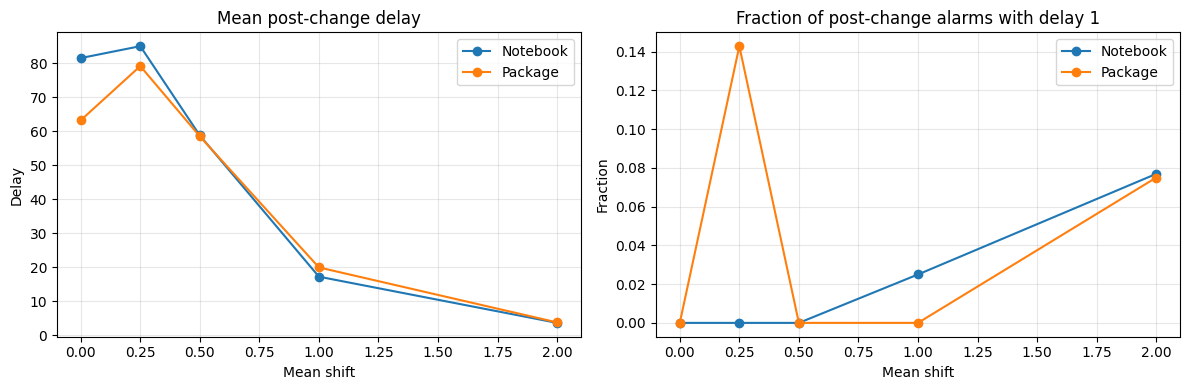

In [27]:
def first_alarm_time_from_outputs(outputs):
    alarm_times = [output["num_samples"] for output in outputs if output["alarm"]]
    return alarm_times[0] if alarm_times else None


def simulate_mean_change_paths(n_paths, stream_len, changepoint, delta, rng_seed):
    if delta == 0.0:
        return draw_grid_samples(
            n_paths=n_paths,
            stream_len=stream_len,
            n_features=1,
            pre_sampler=normal_sampler,
            pre_kwargs={"loc": 0.0, "scale": 1.0},
            rng=rng_seed,
        )[:, :, 0]

    return draw_grid_samples(
        n_paths=n_paths,
        stream_len=stream_len,
        n_features=1,
        pre_sampler=normal_sampler,
        pre_kwargs={"loc": 0.0, "scale": 1.0},
        post_sampler=normal_sampler,
        post_kwargs={"loc": delta, "scale": 1.0},
        changepoint=changepoint,
        rng=rng_seed,
    )[:, :, 0]


def evaluate_notebook_detector(paths, threshold, score_model):
    alarm_times = []
    for path in paths:
        detector = GridDetector(score=score_model, threshold=threshold)
        outputs = run_online_grid_detector(path, detector)
        alarm_times.append(first_alarm_time_from_outputs(outputs))
    return alarm_times


def evaluate_package_detector(paths, threshold, quantiles):
    alarm_times = []
    for path in paths:
        detector = cp.NPFocus(quantiles=quantiles, side="both")
        outputs, _ = run_package_npfocus(path, detector, threshold)
        alarm_times.append(first_alarm_time_from_outputs(outputs))
    return alarm_times


def summarise_alarm_times(alarm_times, changepoint, stream_len):
    alarm_array = np.array(
        [stream_len + 1 if alarm_time is None else alarm_time for alarm_time in alarm_times],
        dtype=np.int64,
    )
    false_alarm_rate = float(np.mean(alarm_array <= changepoint))
    post_change_mask = (alarm_array > changepoint) & (alarm_array <= stream_len)
    post_change_delays = alarm_array[post_change_mask] - changepoint - 1

    summary = {
        "false_alarm_rate": false_alarm_rate,
        "detection_rate": float(np.mean(post_change_mask)),
        "delay_1_rate": float(np.mean(post_change_delays == 1)) if post_change_delays.size else np.nan,
        "mean_delay": float(np.mean(post_change_delays)) if post_change_delays.size else np.nan,
        "median_delay": float(np.median(post_change_delays)) if post_change_delays.size else np.nan,
    }
    return summary


diagnostic_stream_len = 300
diagnostic_changepoint = diagnostic_stream_len // 2
diagnostic_grid = np.linspace(-5, 5, 25)
diagnostic_score_model = NPFOCuS(grid=diagnostic_grid)
diagnostic_calibration_paths = 100
diagnostic_eval_paths = 40
diagnostic_deltas = [0.0, 0.25, 0.5, 1.0, 2.0]

start_time = perf_counter()
diagnostic_npfocus_threshold = calibrate_threshold(
    score=diagnostic_score_model,
    false_alarm_probability=false_alarm_probability,
    stream_len=diagnostic_stream_len,
    n_paths=diagnostic_calibration_paths,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=321,
    n_features=1,
    parallel=False,
)
diagnostic_npfocus_calibration_time = perf_counter() - start_time

start_time = perf_counter()
diagnostic_package_threshold, _ = calibrate_package_npfocus_threshold(
    quantiles=diagnostic_grid.tolist(),
    false_alarm_probability=false_alarm_probability,
    n_paths=diagnostic_calibration_paths,
    stream_len=diagnostic_stream_len,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=321,
)
diagnostic_package_calibration_time = perf_counter() - start_time

print("Diagnostic thresholds")
print(f"  Notebook threshold: {diagnostic_npfocus_threshold:.4f}")
print(f"  Package threshold:  {diagnostic_package_threshold:.4f}")
print(f"  Notebook calibration time: {diagnostic_npfocus_calibration_time:.3f} s")
print(f"  Package calibration time:  {diagnostic_package_calibration_time:.3f} s")
print()

results = []
for delta in diagnostic_deltas:
    paths = simulate_mean_change_paths(
        n_paths=diagnostic_eval_paths,
        stream_len=diagnostic_stream_len,
        changepoint=diagnostic_changepoint,
        delta=delta,
        rng_seed=1000 + int(100 * delta),
    )
    notebook_alarm_times = evaluate_notebook_detector(
        paths,
        threshold=diagnostic_npfocus_threshold,
        score_model=diagnostic_score_model,
    )
    package_alarm_times = evaluate_package_detector(
        paths,
        threshold=diagnostic_package_threshold,
        quantiles=diagnostic_grid.tolist(),
    )

    notebook_summary = summarise_alarm_times(
        notebook_alarm_times,
        changepoint=diagnostic_changepoint,
        stream_len=diagnostic_stream_len,
    )
    package_summary = summarise_alarm_times(
        package_alarm_times,
        changepoint=diagnostic_changepoint,
        stream_len=diagnostic_stream_len,
    )

    results.append(
        {
            "delta": delta,
            "notebook": notebook_summary,
            "package": package_summary,
        }
    )

print(
    "delta | detector | false_alarm_rate | detection_rate | delay_1_rate | mean_delay | median_delay"
)
for row in results:
    for detector_name in ("notebook", "package"):
        stats = row[detector_name]
        print(
            f"{row['delta']:>4.2f} | {detector_name:>8} | "
            f"{stats['false_alarm_rate']:>16.3f} | "
            f"{stats['detection_rate']:>14.3f} | "
            f"{stats['delay_1_rate']:>12.3f} | "
            f"{stats['mean_delay']:>10.3f} | "
            f"{stats['median_delay']:>12.3f}"
        )

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(
    diagnostic_deltas,
    [row["notebook"]["mean_delay"] for row in results],
    marker="o",
    label="Notebook",
)
axes[0].plot(
    diagnostic_deltas,
    [row["package"]["mean_delay"] for row in results],
    marker="o",
    label="Package",
)
axes[0].set_title("Mean post-change delay")
axes[0].set_xlabel("Mean shift")
axes[0].set_ylabel("Delay")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    diagnostic_deltas,
    [row["notebook"]["delay_1_rate"] for row in results],
    marker="o",
    label="Notebook",
)
axes[1].plot(
    diagnostic_deltas,
    [row["package"]["delay_1_rate"] for row in results],
    marker="o",
    label="Package",
)
axes[1].set_title("Fraction of post-change alarms with delay 1")
axes[1].set_xlabel("Mean shift")
axes[1].set_ylabel("Fraction")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Paper-style benchmark

This section runs a more systematic benchmark for the notebook-defined NPFoCUS and `changepoint_online.NPFocus` on the same 25-point grid. It reports:

- Conditional expected detection delay after the changepoint.
- Empirical null average run length, capped by the study horizon.
- Calibration time and average detector runtime per path.

The goal is not to claim a final large-scale simulation result, but to produce a compact comparison that is suitable for inclusion in a draft figure or benchmark table.

Benchmark design
  Grid size: 25
  Stream length: 400
  Changepoint: 201
  Calibration paths: 150
  Null ARL paths: 200
  Delay paths per delta: 100

Thresholds
  Notebook: 76.7801
  Package:  60.6075

Null average run length study
detector  capped_arl0  false_alarm_probability_by_horizon  runtime_ms_per_path
Notebook      388.585                               0.100                9.913
 Package      389.870                               0.085               64.481

Delay and runtime study
 delta detector  conditional_delay_mean  conditional_delay_median  post_change_detection_rate  false_alarm_rate  runtime_ms_per_path
 0.250 Notebook                  98.879                    99.000                       0.330             0.030                9.781
 0.250  Package                 102.788                   105.000                       0.330             0.040               65.011
 0.500 Notebook                  76.306                    65.000                       0.850             0

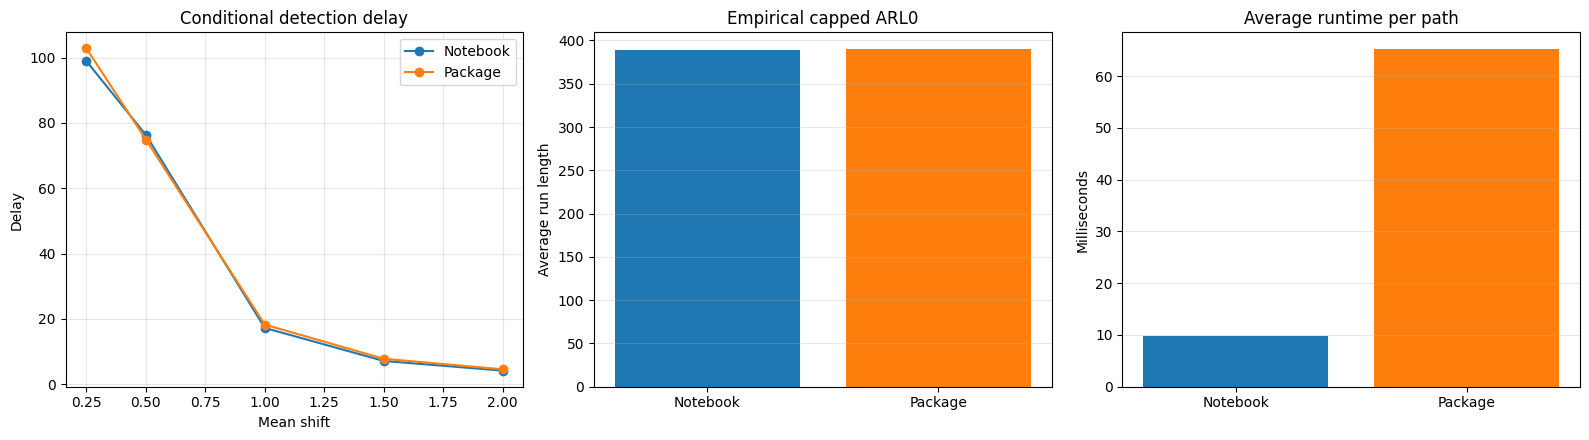

In [28]:
import pandas as pd


def alarm_times_to_capped_run_lengths(alarm_times, stream_len):
    return np.array(
        [stream_len + 1 if alarm_time is None else alarm_time for alarm_time in alarm_times],
        dtype=np.float64,
    )


def conditional_detection_delays(alarm_times, changepoint, stream_len):
    run_lengths = alarm_times_to_capped_run_lengths(alarm_times, stream_len)
    detected_post_change = (run_lengths > changepoint) & (run_lengths <= stream_len)
    delays = run_lengths[detected_post_change] - changepoint - 1
    return delays


def benchmark_notebook_detector(paths, threshold, score_model):
    alarm_times = []
    start_time = perf_counter()
    for path in paths:
        detector = GridDetector(score=score_model, threshold=threshold)
        outputs = run_online_grid_detector(path, detector)
        alarm_times.append(first_alarm_time_from_outputs(outputs))
    elapsed = perf_counter() - start_time
    return alarm_times, elapsed


def benchmark_package_detector(paths, threshold, quantiles):
    alarm_times = []
    start_time = perf_counter()
    for path in paths:
        detector = cp.NPFocus(quantiles=quantiles, side="both")
        outputs, _ = run_package_npfocus(path, detector, threshold)
        alarm_times.append(first_alarm_time_from_outputs(outputs))
    elapsed = perf_counter() - start_time
    return alarm_times, elapsed


study_grid = np.linspace(-5, 5, 25)
study_quantiles = study_grid.tolist()
study_stream_len = 400
study_changepoint = study_stream_len // 2
study_calibration_paths = 150
study_eval_paths = 100
study_null_paths = 200
study_deltas = [0.25, 0.5, 1.0, 1.5, 2.0]
study_score_model = NPFOCuS(grid=study_grid)

start_time = perf_counter()
study_notebook_threshold = calibrate_threshold(
    score=study_score_model,
    false_alarm_probability=false_alarm_probability,
    stream_len=study_stream_len,
    n_paths=study_calibration_paths,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=2026,
    n_features=1,
    parallel=False,
)
study_notebook_calibration_time = perf_counter() - start_time

start_time = perf_counter()
study_package_threshold, _ = calibrate_package_npfocus_threshold(
    quantiles=study_quantiles,
    false_alarm_probability=false_alarm_probability,
    n_paths=study_calibration_paths,
    stream_len=study_stream_len,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=2026,
)
study_package_calibration_time = perf_counter() - start_time

null_paths = simulate_mean_change_paths(
    n_paths=study_null_paths,
    stream_len=study_stream_len,
    changepoint=study_changepoint,
    delta=0.0,
    rng_seed=777,
)

null_notebook_alarm_times, null_notebook_runtime = benchmark_notebook_detector(
    null_paths,
    threshold=study_notebook_threshold,
    score_model=study_score_model,
)
null_package_alarm_times, null_package_runtime = benchmark_package_detector(
    null_paths,
    threshold=study_package_threshold,
    quantiles=study_quantiles,
)

null_notebook_run_lengths = alarm_times_to_capped_run_lengths(
    null_notebook_alarm_times,
    study_stream_len,
)
null_package_run_lengths = alarm_times_to_capped_run_lengths(
    null_package_alarm_times,
    study_stream_len,
)

study_rows = []
runtime_rows = [
    {
        "detector": "Notebook",
        "scenario": "calibration",
        "seconds": study_notebook_calibration_time,
        "ms_per_path": 1000.0 * study_notebook_calibration_time / study_calibration_paths,
    },
    {
        "detector": "Package",
        "scenario": "calibration",
        "seconds": study_package_calibration_time,
        "ms_per_path": 1000.0 * study_package_calibration_time / study_calibration_paths,
    },
    {
        "detector": "Notebook",
        "scenario": "null run",
        "seconds": null_notebook_runtime,
        "ms_per_path": 1000.0 * null_notebook_runtime / study_null_paths,
    },
    {
        "detector": "Package",
        "scenario": "null run",
        "seconds": null_package_runtime,
        "ms_per_path": 1000.0 * null_package_runtime / study_null_paths,
    },
]

for delta in study_deltas:
    alt_paths = simulate_mean_change_paths(
        n_paths=study_eval_paths,
        stream_len=study_stream_len,
        changepoint=study_changepoint,
        delta=delta,
        rng_seed=5000 + int(100 * delta),
    )

    notebook_alarm_times, notebook_runtime = benchmark_notebook_detector(
        alt_paths,
        threshold=study_notebook_threshold,
        score_model=study_score_model,
    )
    package_alarm_times, package_runtime = benchmark_package_detector(
        alt_paths,
        threshold=study_package_threshold,
        quantiles=study_quantiles,
    )

    notebook_delays = conditional_detection_delays(
        notebook_alarm_times,
        changepoint=study_changepoint,
        stream_len=study_stream_len,
    )
    package_delays = conditional_detection_delays(
        package_alarm_times,
        changepoint=study_changepoint,
        stream_len=study_stream_len,
    )

    study_rows.append(
        {
            "delta": delta,
            "detector": "Notebook",
            "conditional_delay_mean": float(np.mean(notebook_delays)) if notebook_delays.size else np.nan,
            "conditional_delay_median": float(np.median(notebook_delays)) if notebook_delays.size else np.nan,
            "post_change_detection_rate": float(np.mean([t is not None and study_changepoint < t <= study_stream_len for t in notebook_alarm_times])),
            "false_alarm_rate": float(np.mean([t is not None and t <= study_changepoint for t in notebook_alarm_times])),
            "runtime_ms_per_path": 1000.0 * notebook_runtime / study_eval_paths,
        }
    )
    study_rows.append(
        {
            "delta": delta,
            "detector": "Package",
            "conditional_delay_mean": float(np.mean(package_delays)) if package_delays.size else np.nan,
            "conditional_delay_median": float(np.median(package_delays)) if package_delays.size else np.nan,
            "post_change_detection_rate": float(np.mean([t is not None and study_changepoint < t <= study_stream_len for t in package_alarm_times])),
            "false_alarm_rate": float(np.mean([t is not None and t <= study_changepoint for t in package_alarm_times])),
            "runtime_ms_per_path": 1000.0 * package_runtime / study_eval_paths,
        }
    )

benchmark_df = pd.DataFrame(study_rows)
runtime_df = pd.DataFrame(runtime_rows)
arl_df = pd.DataFrame(
    [
        {
            "detector": "Notebook",
            "capped_arl0": float(np.mean(null_notebook_run_lengths)),
            "false_alarm_probability_by_horizon": float(np.mean(null_notebook_run_lengths <= study_stream_len)),
            "runtime_ms_per_path": 1000.0 * null_notebook_runtime / study_null_paths,
        },
        {
            "detector": "Package",
            "capped_arl0": float(np.mean(null_package_run_lengths)),
            "false_alarm_probability_by_horizon": float(np.mean(null_package_run_lengths <= study_stream_len)),
            "runtime_ms_per_path": 1000.0 * null_package_runtime / study_null_paths,
        },
    ]
)

print("Benchmark design")
print(f"  Grid size: {study_grid.size}")
print(f"  Stream length: {study_stream_len}")
print(f"  Changepoint: {study_changepoint + 1}")
print(f"  Calibration paths: {study_calibration_paths}")
print(f"  Null ARL paths: {study_null_paths}")
print(f"  Delay paths per delta: {study_eval_paths}")
print()
print("Thresholds")
print(f"  Notebook: {study_notebook_threshold:.4f}")
print(f"  Package:  {study_package_threshold:.4f}")
print()
print("Null average run length study")
print(arl_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("Delay and runtime study")
print(benchmark_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("Calibration and null-run runtime summary")
print(runtime_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for detector_name, detector_df in benchmark_df.groupby("detector"):
    axes[0].plot(
        detector_df["delta"],
        detector_df["conditional_delay_mean"],
        marker="o",
        label=detector_name,
    )
axes[0].set_title("Conditional detection delay")
axes[0].set_xlabel("Mean shift")
axes[0].set_ylabel("Delay")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(
    arl_df["detector"],
    arl_df["capped_arl0"],
    color=["C0", "C1"],
)
axes[1].set_title("Empirical capped ARL0")
axes[1].set_ylabel("Average run length")
axes[1].grid(True, axis="y", alpha=0.3)

runtime_summary_df = benchmark_df.groupby("detector", as_index=False)["runtime_ms_per_path"].mean()
axes[2].bar(
    runtime_summary_df["detector"],
    runtime_summary_df["runtime_ms_per_path"],
    color=["C0", "C1"],
)
axes[2].set_title("Average runtime per path")
axes[2].set_ylabel("Milliseconds")
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Paper-style benchmark: Poisson change in rate

This repeats the same benchmark design for a Poisson rate change. Both detectors are calibrated under a Poisson null, then compared on:

- Conditional post-change detection delay.
- Empirical capped ARL0 under the null.
- Calibration and run-time cost.

The comparison again uses a shared 25-point grid.

Poisson benchmark design
  Grid size: 25
  Stream length: 400
  Pre-change rate: 2.0
  Changepoint: 201
  Calibration paths: 150
  Null ARL paths: 200
  Delay paths per post-rate: 100

Thresholds
  Notebook: 164.5033
  Package:  113.9727

Null average run length study
detector  capped_arl0  false_alarm_probability_by_horizon  runtime_ms_per_path
Notebook      393.065                               0.045               10.357
 Package      395.435                               0.040               76.195

Delay and runtime study
 post_rate detector  conditional_delay_mean  conditional_delay_median  post_change_detection_rate  false_alarm_rate  runtime_ms_per_path
     2.500 Notebook                 101.579                    85.500                       0.380             0.040               10.952
     2.500  Package                 103.182                   102.000                       0.550             0.020               74.992
     3.000 Notebook                  49.149               

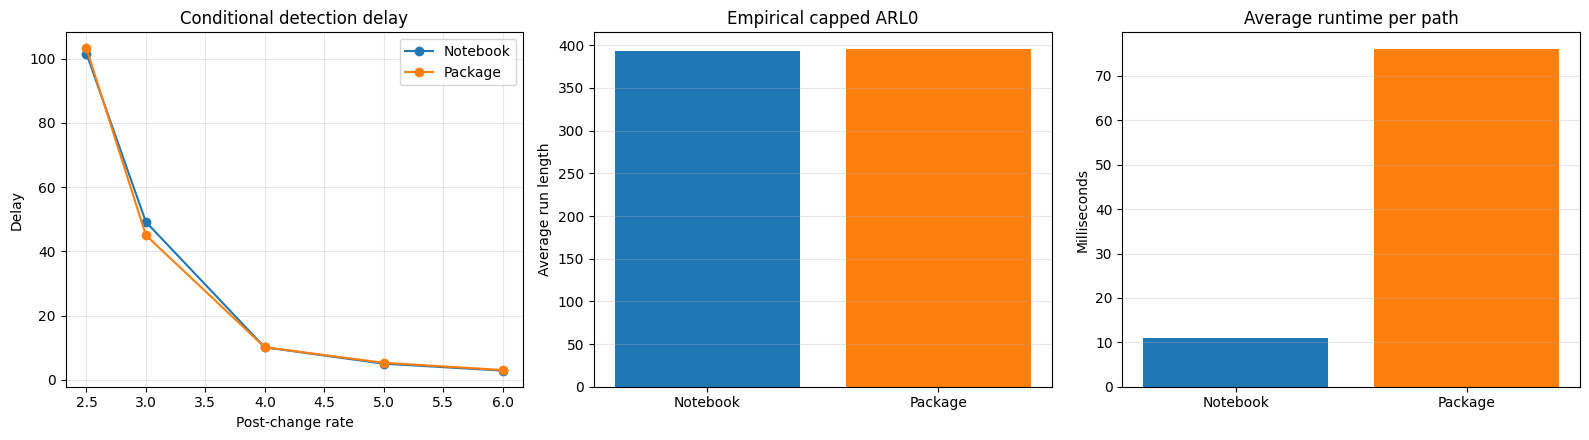

In [29]:
def poisson_sampler(lam=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return rng.poisson(lam=lam)


def simulate_poisson_rate_paths(
    n_paths,
    stream_len,
    changepoint,
    pre_rate,
    post_rate=None,
    rng_seed=0,
):
    if post_rate is None:
        return draw_grid_samples(
            n_paths=n_paths,
            stream_len=stream_len,
            n_features=1,
            pre_sampler=poisson_sampler,
            pre_kwargs={"lam": pre_rate},
            rng=rng_seed,
        )[:, :, 0]

    return draw_grid_samples(
        n_paths=n_paths,
        stream_len=stream_len,
        n_features=1,
        pre_sampler=poisson_sampler,
        pre_kwargs={"lam": pre_rate},
        post_sampler=poisson_sampler,
        post_kwargs={"lam": post_rate},
        changepoint=changepoint,
        rng=rng_seed,
    )[:, :, 0]


poisson_pre_rate = 2.0
poisson_post_rates = [2.5, 3.0, 4.0, 5.0, 6.0]
poisson_stream_len = 400
poisson_changepoint = poisson_stream_len // 2
poisson_grid = np.linspace(0.0, 8.0, 25)
poisson_quantiles = poisson_grid.tolist()
poisson_calibration_paths = 150
poisson_eval_paths = 100
poisson_null_paths = 200
poisson_score_model = NPFOCuS(grid=poisson_grid)

start_time = perf_counter()
poisson_notebook_threshold = calibrate_threshold(
    score=poisson_score_model,
    false_alarm_probability=false_alarm_probability,
    stream_len=poisson_stream_len,
    n_paths=poisson_calibration_paths,
    pre_sampler=poisson_sampler,
    pre_kwargs={"lam": poisson_pre_rate},
    rng=4242,
    n_features=1,
    parallel=False,
)
poisson_notebook_calibration_time = perf_counter() - start_time

start_time = perf_counter()
poisson_package_threshold, _ = calibrate_package_npfocus_threshold(
    quantiles=poisson_quantiles,
    false_alarm_probability=false_alarm_probability,
    n_paths=poisson_calibration_paths,
    stream_len=poisson_stream_len,
    pre_sampler=poisson_sampler,
    pre_kwargs={"lam": poisson_pre_rate},
    rng=4242,
)
poisson_package_calibration_time = perf_counter() - start_time

poisson_null_paths_array = simulate_poisson_rate_paths(
    n_paths=poisson_null_paths,
    stream_len=poisson_stream_len,
    changepoint=poisson_changepoint,
    pre_rate=poisson_pre_rate,
    post_rate=None,
    rng_seed=1717,
)

poisson_null_notebook_alarm_times, poisson_null_notebook_runtime = benchmark_notebook_detector(
    poisson_null_paths_array,
    threshold=poisson_notebook_threshold,
    score_model=poisson_score_model,
)
poisson_null_package_alarm_times, poisson_null_package_runtime = benchmark_package_detector(
    poisson_null_paths_array,
    threshold=poisson_package_threshold,
    quantiles=poisson_quantiles,
)

poisson_null_notebook_run_lengths = alarm_times_to_capped_run_lengths(
    poisson_null_notebook_alarm_times,
    poisson_stream_len,
)
poisson_null_package_run_lengths = alarm_times_to_capped_run_lengths(
    poisson_null_package_alarm_times,
    poisson_stream_len,
)

poisson_rows = []
poisson_runtime_rows = [
    {
        "detector": "Notebook",
        "scenario": "calibration",
        "seconds": poisson_notebook_calibration_time,
        "ms_per_path": 1000.0 * poisson_notebook_calibration_time / poisson_calibration_paths,
    },
    {
        "detector": "Package",
        "scenario": "calibration",
        "seconds": poisson_package_calibration_time,
        "ms_per_path": 1000.0 * poisson_package_calibration_time / poisson_calibration_paths,
    },
    {
        "detector": "Notebook",
        "scenario": "null run",
        "seconds": poisson_null_notebook_runtime,
        "ms_per_path": 1000.0 * poisson_null_notebook_runtime / poisson_null_paths,
    },
    {
        "detector": "Package",
        "scenario": "null run",
        "seconds": poisson_null_package_runtime,
        "ms_per_path": 1000.0 * poisson_null_package_runtime / poisson_null_paths,
    },
]

for post_rate in poisson_post_rates:
    alt_paths = simulate_poisson_rate_paths(
        n_paths=poisson_eval_paths,
        stream_len=poisson_stream_len,
        changepoint=poisson_changepoint,
        pre_rate=poisson_pre_rate,
        post_rate=post_rate,
        rng_seed=7000 + int(100 * post_rate),
    )

    notebook_alarm_times, notebook_runtime = benchmark_notebook_detector(
        alt_paths,
        threshold=poisson_notebook_threshold,
        score_model=poisson_score_model,
    )
    package_alarm_times, package_runtime = benchmark_package_detector(
        alt_paths,
        threshold=poisson_package_threshold,
        quantiles=poisson_quantiles,
    )

    notebook_delays = conditional_detection_delays(
        notebook_alarm_times,
        changepoint=poisson_changepoint,
        stream_len=poisson_stream_len,
    )
    package_delays = conditional_detection_delays(
        package_alarm_times,
        changepoint=poisson_changepoint,
        stream_len=poisson_stream_len,
    )

    poisson_rows.append(
        {
            "post_rate": post_rate,
            "detector": "Notebook",
            "conditional_delay_mean": float(np.mean(notebook_delays)) if notebook_delays.size else np.nan,
            "conditional_delay_median": float(np.median(notebook_delays)) if notebook_delays.size else np.nan,
            "post_change_detection_rate": float(np.mean([t is not None and poisson_changepoint < t <= poisson_stream_len for t in notebook_alarm_times])),
            "false_alarm_rate": float(np.mean([t is not None and t <= poisson_changepoint for t in notebook_alarm_times])),
            "runtime_ms_per_path": 1000.0 * notebook_runtime / poisson_eval_paths,
        }
    )
    poisson_rows.append(
        {
            "post_rate": post_rate,
            "detector": "Package",
            "conditional_delay_mean": float(np.mean(package_delays)) if package_delays.size else np.nan,
            "conditional_delay_median": float(np.median(package_delays)) if package_delays.size else np.nan,
            "post_change_detection_rate": float(np.mean([t is not None and poisson_changepoint < t <= poisson_stream_len for t in package_alarm_times])),
            "false_alarm_rate": float(np.mean([t is not None and t <= poisson_changepoint for t in package_alarm_times])),
            "runtime_ms_per_path": 1000.0 * package_runtime / poisson_eval_paths,
        }
    )

poisson_benchmark_df = pd.DataFrame(poisson_rows)
poisson_runtime_df = pd.DataFrame(poisson_runtime_rows)
poisson_arl_df = pd.DataFrame(
    [
        {
            "detector": "Notebook",
            "capped_arl0": float(np.mean(poisson_null_notebook_run_lengths)),
            "false_alarm_probability_by_horizon": float(np.mean(poisson_null_notebook_run_lengths <= poisson_stream_len)),
            "runtime_ms_per_path": 1000.0 * poisson_null_notebook_runtime / poisson_null_paths,
        },
        {
            "detector": "Package",
            "capped_arl0": float(np.mean(poisson_null_package_run_lengths)),
            "false_alarm_probability_by_horizon": float(np.mean(poisson_null_package_run_lengths <= poisson_stream_len)),
            "runtime_ms_per_path": 1000.0 * poisson_null_package_runtime / poisson_null_paths,
        },
    ]
)

print("Poisson benchmark design")
print(f"  Grid size: {poisson_grid.size}")
print(f"  Stream length: {poisson_stream_len}")
print(f"  Pre-change rate: {poisson_pre_rate}")
print(f"  Changepoint: {poisson_changepoint + 1}")
print(f"  Calibration paths: {poisson_calibration_paths}")
print(f"  Null ARL paths: {poisson_null_paths}")
print(f"  Delay paths per post-rate: {poisson_eval_paths}")
print()
print("Thresholds")
print(f"  Notebook: {poisson_notebook_threshold:.4f}")
print(f"  Package:  {poisson_package_threshold:.4f}")
print()
print("Null average run length study")
print(poisson_arl_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("Delay and runtime study")
print(poisson_benchmark_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("Calibration and null-run runtime summary")
print(poisson_runtime_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for detector_name, detector_df in poisson_benchmark_df.groupby("detector"):
    axes[0].plot(
        detector_df["post_rate"],
        detector_df["conditional_delay_mean"],
        marker="o",
        label=detector_name,
    )
axes[0].set_title("Conditional detection delay")
axes[0].set_xlabel("Post-change rate")
axes[0].set_ylabel("Delay")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(
    poisson_arl_df["detector"],
    poisson_arl_df["capped_arl0"],
    color=["C0", "C1"],
)
axes[1].set_title("Empirical capped ARL0")
axes[1].set_ylabel("Average run length")
axes[1].grid(True, axis="y", alpha=0.3)

poisson_runtime_summary_df = poisson_benchmark_df.groupby("detector", as_index=False)["runtime_ms_per_path"].mean()
axes[2].bar(
    poisson_runtime_summary_df["detector"],
    poisson_runtime_summary_df["runtime_ms_per_path"],
    color=["C0", "C1"],
)
axes[2].set_title("Average runtime per path")
axes[2].set_ylabel("Milliseconds")
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Calibration of threshold using average run length

Fixed detector threshold: 8.000
Fixed score penalty: 1.000
First alarm time: 113


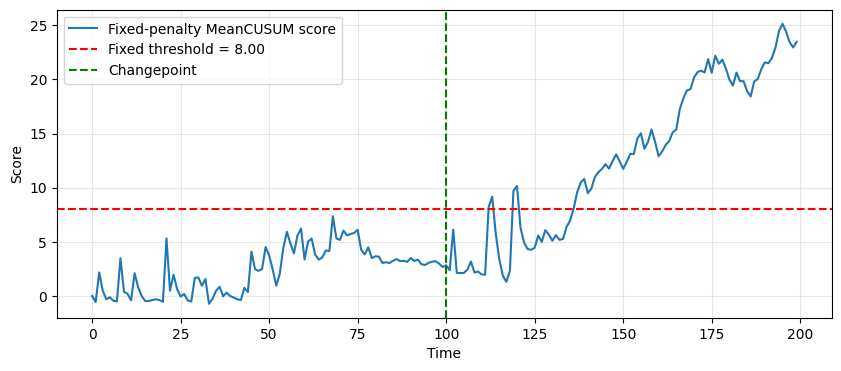

In [33]:
from gridcp.scores._mean_cusum import MeanCUSUMState, mean_cusum_score


@dataclass(frozen=True, slots=True)
class FixedPenaltyMeanCUSUM:
    n_features: int = 1
    penalty: float = 1.0

    def init_state(self) -> MeanCUSUMState:
        return MeanCUSUMState(sum=np.zeros(self.n_features))

    def update(self, state: MeanCUSUMState, x) -> MeanCUSUMState:
        x_arr = np.asarray(x, dtype=np.float64).reshape(-1)
        if x_arr.size != self.n_features:
            raise ValueError(
                f"Expected observation of size {self.n_features}, got {x_arr.size}."
            )
        return MeanCUSUMState(
            n_samples=state.n_samples + 1,
            sum=state.sum + x_arr,
        )

    def compute_penalised_scores(
        self,
        state: MeanCUSUMState,
        grid_states: list[MeanCUSUMState],
    ) -> np.ndarray:
        if len(grid_states) == 0:
            raise ValueError("grid_states is empty.")

        grid_sums = np.stack([st.sum for st in grid_states])
        grid_n_samples = np.array([st.n_samples for st in grid_states], dtype=np.int64)
        scores = mean_cusum_score(
            total_sum=state.sum,
            before_sums=grid_sums,
            total_samples=state.n_samples,
            before_samples=grid_n_samples,
        )
        return scores / self.penalty


# This helper keeps the detector state if you want to inspect it afterwards.
def run_grid_detector_with_states(data, detector: GridDetector):
    state = detector.init_state()
    states = [state]
    outputs = []

    for x in np.asarray(data):
        state, output = detector.update(state, x)
        states.append(state)
        outputs.append(output)

    return states, outputs


stream_length = 200
fixed_threshold_value = 8.0
fixed_penalty_score = FixedPenaltyMeanCUSUM(n_features=1, penalty=1.0)
fixed_threshold_detector = GridDetector(
    score=fixed_penalty_score,
    threshold=fixed_threshold_value,
)

x_demo = np.random.normal(loc=0.0, scale=1.0, size=(stream_length, 1))
x_demo[stream_length // 2 :] += 0.75

_, fixed_threshold_outputs = run_grid_detector_with_states(
    x_demo,
    fixed_threshold_detector,
)
fixed_threshold_alarm_times = [
    output["num_samples"] for output in fixed_threshold_outputs if output["alarm"]
]
fixed_threshold_scores = np.array(
    [output["max_score"] for output in fixed_threshold_outputs],
    dtype=np.float64,
)

print(f"Fixed detector threshold: {fixed_threshold_value:.3f}")
print(f"Fixed score penalty: {fixed_penalty_score.penalty:.3f}")
print(f"First alarm time: {fixed_threshold_alarm_times[0] if fixed_threshold_alarm_times else None}")

plt.figure(figsize=(10, 4))
plt.plot(fixed_threshold_scores, label="Fixed-penalty MeanCUSUM score")
plt.axhline(
    fixed_threshold_value,
    color="red",
    linestyle="--",
    label=f"Fixed threshold = {fixed_threshold_value:.2f}",
)
plt.axvline(stream_length // 2, color="green", linestyle="--", label="Changepoint")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Null waiting times for fixed-threshold MeanCUSUM

This cell calibrates the fixed-penalty MeanCUSUM detector for horizon 1000 under the Gaussian null, then studies the waiting time to alarm on a long null stream with detector resets after each alarm. If the waiting times are approximately exponential, the empirical survival curve should be close to the fitted exponential survival function and the coefficient of variation should be close to 1.

Fixed-threshold MeanCUSUM calibrated at horizon 1000
  Threshold: 18.1875
  Calibration paths: 2000
  Calibration time: 36.573 s

Null waiting-time experiment
  Long null stream length: 2500000
  Number of observed alarms: 120
  Runtime: 44.800 s
  Empirical mean waiting time: 17630.208
  Empirical median waiting time: 13481.000
  Empirical std(waiting time): 18256.594
  Empirical CV: 1.036
  Exponential mean implied by alpha over 1000: 19495.726
  Geometric mean implied by alpha over 1000: 19496.226

Exponential fit diagnostics
  Fitted exponential scale: 17630.208
  KS statistic: 0.0668
  KS p-value: 0.6331

Geometric fit diagnostics
  Fitted geometric success probability: 0.000057
  Alpha-implied geometric success probability: 0.000051
  Fitted geometric mean: 17630.208
  Fitted geometric CV: 1.000
  KS statistic (heuristic for discrete law): 0.0668
  KS p-value (heuristic for discrete law): 0.6329


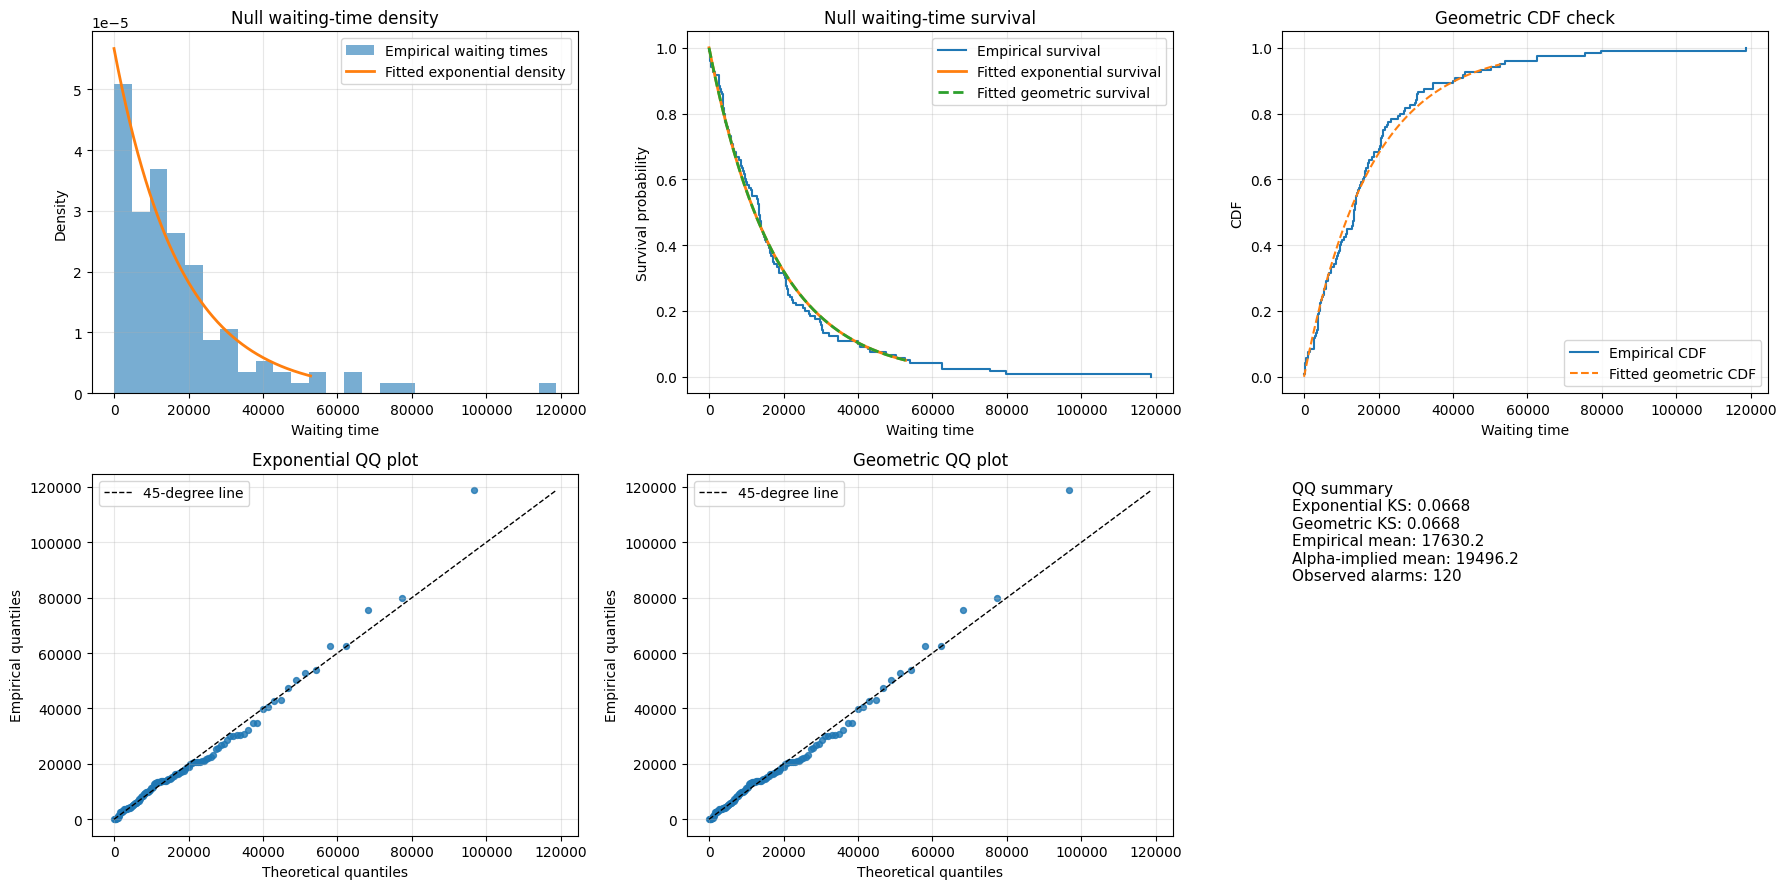

In [36]:
from scipy import stats


def run_resetting_detector_waiting_times(
    data,
    detector: GridDetector,
    *,
    target_alarms: int,
) -> tuple[np.ndarray, list[dict]]:
    waiting_times = []
    outputs = []
    state = detector.init_state()
    samples_since_reset = 0

    for x in np.asarray(data):
        samples_since_reset += 1
        state, output = detector.update(state, x)
        outputs.append(output)
        if output["alarm"]:
            waiting_times.append(samples_since_reset)
            state = detector.init_state()
            samples_since_reset = 0
            if len(waiting_times) >= target_alarms:
                break

    return np.asarray(waiting_times, dtype=np.int64), outputs


calibration_stream_len = 1000
calibration_paths = 2000
fixed_penalty_for_calibration = 1.0
fixed_horizon_score = FixedPenaltyMeanCUSUM(
    n_features=1,
    penalty=fixed_penalty_for_calibration,
)

start_time = perf_counter()
fixed_threshold_len1000 = calibrate_threshold(
    score=fixed_horizon_score,
    false_alarm_probability=false_alarm_probability,
    stream_len=calibration_stream_len,
    n_paths=calibration_paths,
    pre_sampler=normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    rng=2027,
    n_features=1,
    parallel=False,
)
fixed_calibration_time = perf_counter() - start_time

exponential_mean_from_alpha = -calibration_stream_len / np.log(
    1.0 - false_alarm_probability
)
geometric_p_from_alpha = 1.0 - (1.0 - false_alarm_probability) ** (
    1.0 / calibration_stream_len
)
geometric_mean_from_alpha = 1.0 / geometric_p_from_alpha

long_null_stream_len = 2_500_000
target_alarm_count = 120
long_null_stream = np.random.default_rng(2028).normal(
    loc=0.0,
    scale=1.0,
    size=(long_null_stream_len, 1),
)

fixed_len1000_detector = GridDetector(
    score=fixed_horizon_score,
    threshold=fixed_threshold_len1000,
)

start_time = perf_counter()
waiting_times, waiting_time_outputs = run_resetting_detector_waiting_times(
    long_null_stream,
    fixed_len1000_detector,
    target_alarms=target_alarm_count,
)
waiting_time_runtime = perf_counter() - start_time

if waiting_times.size == 0:
    raise RuntimeError("No alarms were observed. Increase the null stream length.")

fitted_scale = float(np.mean(waiting_times))
fitted_geometric_p = 1.0 / fitted_scale
ks_result = stats.kstest(
    waiting_times,
    stats.expon(loc=0.0, scale=fitted_scale).cdf,
)
geometric_ks_result = stats.kstest(
    waiting_times,
    stats.geom(p=fitted_geometric_p, loc=0).cdf,
)

print("Fixed-threshold MeanCUSUM calibrated at horizon 1000")
print(f"  Threshold: {fixed_threshold_len1000:.4f}")
print(f"  Calibration paths: {calibration_paths}")
print(f"  Calibration time: {fixed_calibration_time:.3f} s")
print()
print("Null waiting-time experiment")
print(f"  Long null stream length: {long_null_stream_len}")
print(f"  Number of observed alarms: {waiting_times.size}")
print(f"  Runtime: {waiting_time_runtime:.3f} s")
print(f"  Empirical mean waiting time: {np.mean(waiting_times):.3f}")
print(f"  Empirical median waiting time: {np.median(waiting_times):.3f}")
print(f"  Empirical std(waiting time): {np.std(waiting_times, ddof=1):.3f}")
print(f"  Empirical CV: {np.std(waiting_times, ddof=1) / np.mean(waiting_times):.3f}")
print(
    f"  Exponential mean implied by alpha over 1000: {exponential_mean_from_alpha:.3f}"
)
print(
    f"  Geometric mean implied by alpha over 1000: {geometric_mean_from_alpha:.3f}"
)
print()
print("Exponential fit diagnostics")
print(f"  Fitted exponential scale: {fitted_scale:.3f}")
print(f"  KS statistic: {ks_result.statistic:.4f}")
print(f"  KS p-value: {ks_result.pvalue:.4f}")
print()
print("Geometric fit diagnostics")
print(f"  Fitted geometric success probability: {fitted_geometric_p:.6f}")
print(f"  Alpha-implied geometric success probability: {geometric_p_from_alpha:.6f}")
print(f"  Fitted geometric mean: {1.0 / fitted_geometric_p:.3f}")
print(
    f"  Fitted geometric CV: {np.sqrt(1.0 - fitted_geometric_p):.3f}"
)
print("  KS statistic (heuristic for discrete law): "
      f"{geometric_ks_result.statistic:.4f}")
print("  KS p-value (heuristic for discrete law): "
      f"{geometric_ks_result.pvalue:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

x_grid = np.linspace(0.0, np.percentile(waiting_times, 95), 200)
axes[0].hist(
    waiting_times,
    bins=25,
    density=True,
    alpha=0.6,
    label="Empirical waiting times",
)
axes[0].plot(
    x_grid,
    stats.expon(scale=fitted_scale).pdf(x_grid),
    linewidth=2,
    label="Fitted exponential density",
)
axes[0].set_title("Null waiting-time density")
axes[0].set_xlabel("Waiting time")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_waiting_times = np.sort(waiting_times)
empirical_survival = 1.0 - np.arange(1, waiting_times.size + 1) / waiting_times.size
axes[1].step(
    sorted_waiting_times,
    empirical_survival,
    where="post",
    label="Empirical survival",
)
axes[1].plot(
    x_grid,
    stats.expon(scale=fitted_scale).sf(x_grid),
    linewidth=2,
    label="Fitted exponential survival",
)
axes[1].plot(
    x_grid,
    (1.0 - fitted_geometric_p) ** x_grid,
    linewidth=2,
    linestyle="--",
    label="Fitted geometric survival",
)
axes[1].set_title("Null waiting-time survival")
axes[1].set_xlabel("Waiting time")
axes[1].set_ylabel("Survival probability")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

geom_x = np.arange(1, int(np.percentile(waiting_times, 95)) + 1)
empirical_cdf = np.arange(1, waiting_times.size + 1) / waiting_times.size
axes[2].step(
    sorted_waiting_times,
    empirical_cdf,
    where="post",
    label="Empirical CDF",
)
axes[2].step(
    geom_x,
    stats.geom(p=fitted_geometric_p, loc=0).cdf(geom_x),
    where="post",
    linestyle="--",
    label="Fitted geometric CDF",
)
axes[2].set_title("Geometric CDF check")
axes[2].set_xlabel("Waiting time")
axes[2].set_ylabel("CDF")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

qq_probs = (np.arange(1, waiting_times.size + 1) - 0.5) / waiting_times.size
exp_theoretical_quantiles = stats.expon(scale=fitted_scale).ppf(qq_probs)
geom_theoretical_quantiles = stats.geom(p=fitted_geometric_p, loc=0).ppf(qq_probs)

axes[3].scatter(
    exp_theoretical_quantiles,
    sorted_waiting_times,
    s=18,
    alpha=0.8,
)
exp_qq_max = max(np.max(exp_theoretical_quantiles), np.max(sorted_waiting_times))
axes[3].plot(
    [0.0, exp_qq_max],
    [0.0, exp_qq_max],
    linestyle="--",
    color="black",
    linewidth=1,
    label="45-degree line",
)
axes[3].set_title("Exponential QQ plot")
axes[3].set_xlabel("Theoretical quantiles")
axes[3].set_ylabel("Empirical quantiles")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[4].scatter(
    geom_theoretical_quantiles,
    sorted_waiting_times,
    s=18,
    alpha=0.8,
)
geom_qq_max = max(np.max(geom_theoretical_quantiles), np.max(sorted_waiting_times))
axes[4].plot(
    [0.0, geom_qq_max],
    [0.0, geom_qq_max],
    linestyle="--",
    color="black",
    linewidth=1,
    label="45-degree line",
)
axes[4].set_title("Geometric QQ plot")
axes[4].set_xlabel("Theoretical quantiles")
axes[4].set_ylabel("Empirical quantiles")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

axes[5].axis("off")
axes[5].text(
    0.02,
    0.98,
    "QQ summary\n"
    f"Exponential KS: {ks_result.statistic:.4f}\n"
    f"Geometric KS: {geometric_ks_result.statistic:.4f}\n"
    f"Empirical mean: {np.mean(waiting_times):.1f}\n"
    f"Alpha-implied mean: {geometric_mean_from_alpha:.1f}\n"
    f"Observed alarms: {waiting_times.size}",
    va="top",
    ha="left",
    fontsize=11,
)

plt.tight_layout()
plt.show()

# Old stuff:

In [13]:
@nb.njit
def h(y):
    return y


@nb.njit
def f(sum_pre_j, sum_post_j, g, t):
    res = math.sqrt(1.0 * g / (t * (t - g))) * sum_pre_j
    res = res - math.sqrt(1.0 * (t - g) / t / g) * sum_post_j
    return np.sum(res * res)


@nb.njit
def penalty(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg

    return rr

In [29]:
N = 1000
K = 1000
p = 10
null_dist = np.random.normal
null_args = (0, 1)  # mean=0, std=1
sample = mc_max_statistics(
    N=N,
    K=K,
    p=p,
    h=h,
    f=f,
    penalty=penalty,
    null_dist=null_dist,
    penalty_constant=0.0,
    null_args=null_args,
    null_kwargs=None,
    auxiliary_data=None,
)

TypeError: mc_max_statistics() got an unexpected keyword argument 'null_args'

In [ ]:
critical_value = np.percentile(sample, 95)
print(f"Critical value at 95%: {critical_value}")

In [ ]:
xs = np.random.normal(0, 1, (N, p))
xs[(N // 2) :] += 0.2  # Introduce a change point at iteration 8000

state = init_state(p, h, f, penalty, critical_value)
for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i + 1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

### Multivariate change in mean or covariance

In [ ]:
@nb.njit
def h_mean_cov(y: np.ndarray) -> np.ndarray:
    p = y.shape[0]
    yy = np.outer(y, y)
    out = np.empty((p + 1, p), dtype=y.dtype)
    out[0] = y
    out[1:] = yy

    return out


@nb.njit
def f_mean_cov(sum_pre_j, sum_post_j, g, t):
    """
    GLR-type statistic for a change in both mean and covariance
    in multivariate Gaussian data.

    sum_pre_j: sum of h(y) over segment 1  (shape (p+1, p))
    sum_post_j: sum of h(y) over segment 2 (shape (p+1, p))
    g: candidate change-point (segment 1 length)
    t: total sample size
    """
    n1 = t - g
    n2 = g

    p = sum_pre_j.shape[0]  # dimension of data
    if n1 <= p or n2 <= p:
        return 0.0

    totalsum = sum_pre_j + sum_post_j
    sum_pre_j_id = sum_pre_j[0]
    sum_post_j_id = sum_post_j[0]
    totalsum_id = totalsum[0]

    sum_pre_j_cov = sum_pre_j[1:]
    sum_post_j_cov = sum_post_j[1:]
    totalsum_cov = totalsum[1:]

    Sigma_tot = (totalsum_cov - np.outer(totalsum_id, totalsum_id) / t) / t
    Sigma_pre_j = (sum_pre_j_cov - np.outer(sum_pre_j_id, sum_pre_j_id) / n1) / n1
    Sigma_post_j = (sum_post_j_cov - np.outer(sum_post_j_id, sum_post_j_id) / n2) / n2

    # GLR statistic: t * log|Sigma| - g* log|Sigma1| - (t-g) * log|Sigma2|
    # Use slogdet for numerical stability
    sign0, logdet0 = np.linalg.slogdet(Sigma_tot)
    sign1, logdet1 = np.linalg.slogdet(Sigma_pre_j)
    sign2, logdet2 = np.linalg.slogdet(Sigma_post_j)

    if False:
        # If any covariance is singular (sign <= 0), treat statistic as 0
        if sign0 <= 0 or sign1 <= 0 or sign2 <= 0:
            if sign0 <= 0:
                print("Sigma_tot is singular or not positive definite")
            if sign1 <= 0:
                print("Sigma_pre_j is singular or not positive definite")
            if sign2 <= 0:
                print("Sigma_post_j is singular or not positive definite")
            return 0.0

    LR = t * logdet0 - n1 * logdet1 - n2 * logdet2
    df = p + (p * (p + 1)) // 2  # Number of parameters in mean+covariance

    return LR - df


@nb.njit
def penalty_mean_cov(g, t, p):
    df = (p * (p + 1)) // 2 + p
    logg = fastlog(t / 0.05)
    rr = math.sqrt(df * logg) + logg

    return rr

In [ ]:
p = 5
S1 = np.zeros((p + 1, p))
S2 = np.zeros((p + 1, p))

T1 = np.zeros((p + 1, p))
T2 = np.zeros((p + 1, p))

NN = 100
for i in range(NN):
    y = np.random.normal(0, 1, p)
    h_y = h_mean_cov(y)
    S1 += h_y
    hy = h_mean_cov(y / 2)
    T1 += hy

    y = np.random.normal(0, 1, p)
    h_y = h_mean_cov(y)
    S2 += h_y
    hy = h_mean_cov(y / 2)
    T2 += hy


r1 = f_mean_cov(S1, S2, 50, 100)
r2 = f_mean_cov(T1, T2, 50, 100)
print(r1)
print(r2)

In [ ]:
N = 1000
K = 1000
p = 10
null_dist = np.random.normal
null_args = (0, 1)  # mean=0, std=1
sample = mc_max_statistics(
    N=N,
    K=K,
    p=p,
    h=h_mean_cov,
    f=f_mean_cov,
    penalty=penalty_mean_cov,
    null_dist=null_dist,
    penalty_constant=0.0,
    null_args=null_args,
    null_kwargs=None,
    auxiliary_data=None,
)

In [ ]:
critical_value = np.percentile(sample, 95)
print(f"Critical value at 95%: {critical_value}")

In [ ]:
xs = np.random.normal(0, 1, (N, p))
xs[(N // 2) :] += 0.4

state = init_state(p, h_mean_cov, f_mean_cov, penalty_mean_cov, critical_value)
for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i + 1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

In [ ]:
xs = np.zeros((N, p))
xs[: (N // 2)] = np.random.normal(0, 1, (N // 2, p))
xs[(N // 2) :] = np.random.normal(0, 0.5, (N // 2, p))  # Introduce a changepoint


state = init_state(p, h_mean_cov, f_mean_cov, penalty_mean_cov, critical_value)
for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i + 1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

In [ ]:
state

### General likelihood ratio test using Numba, requiring gradients

In [ ]:
## Specific examples are for Bernoulli with natural param theta = log(p/(1-p)) and A(theta) = log(1 + exp(theta))


from matplotlib.pylab import inf


@nb.njit
def h(y):
    return y


@nb.njit
def A_func(theta):
    return np.log(1.0 + np.exp(theta)).sum()


@nb.njit
def grad_A(theta):
    ee = np.exp(theta)
    return ee / (1.0 + ee)


@nb.njit
def hess_A(theta):
    H = np.zeros((1, 1), dtype=np.float64)
    ee = np.exp(theta)
    H[0, 0] = (ee / ((1.0 + ee) ** 2)).sum()
    return H


@nb.njit
def penalty(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg

    return rr


## The below should be general


@nb.njit
def logLik(theta, S, n):
    # S is cumulative sum!
    # n is total sample size

    # if S is numerically zero or n, we return zero:
    if np.all(np.abs(S) < 1e-10) or np.all(np.abs(S - n) < 1e-10):
        return 0.0
    A_theta = A_func(theta)
    return np.dot(theta, S) - n * A_theta


@nb.njit
def newton_mle(
    S, n, theta_init, A_func, grad_A, hess_A, logLik, tol=1e-12, max_iter=1000
):
    """
    Maximize logLik(theta; S, n) = theta @ S - n * A_func(theta)
    over theta ∈ R^v using safeguarded Newton.

    Inputs
    ------
    S : 1D array (v,)
        Sum of sufficient statistics.
    n : int
        Number of observations.
    theta_init : 1D array (v,)
        Starting point (e.g. previous MLE or some fixed value).
    tol : float
        Stop when ||grad||_inf < tol.
    max_iter : int
        Hard cap on number of iterations.

    Returns
    -------
    theta_hat : 1D array (v,)
    converged : boolean
    """

    if (np.abs(S) < 1e-10).all():
        return np.array([-np.inf]), True

    if (np.abs(S - n) < 1e-10).all():
        return np.array([np.inf]), True

    theta = theta_init
    v = theta.shape[0]

    # Small ridge for numerical stability of Hessian
    ridge = 1e-8

    # current log-likelihood
    ll_old = logLik(theta, S, n)

    for it in range(max_iter):
        # Gradient of log-likelihood: S - n * grad_A(theta)
        gA = grad_A(theta)  # shape (v,)
        grad = S - n * gA  # shape (v,)

        # Check convergence: ||grad||_inf < tol
        max_abs_grad = 0.0
        for i in range(v):
            val = grad[i]
            if val < 0.0:
                val = -val
            if val > max_abs_grad:
                max_abs_grad = val
        if max_abs_grad < tol:
            return theta, True

        # Hessian of log-likelihood: H = -n * hess_A(theta)
        HA = hess_A(theta)  # shape (v, v)
        H = np.empty_like(HA)
        for i in range(v):
            for j in range(v):
                H[i, j] = -n * HA[i, j]
        # Add a small ridge to diagonal: H ← H − ridge * I
        # (H is negative semidefinite; we move it slightly more negative
        # to make it better-conditioned)
        for i in range(v):
            H[i, i] = H[i, i] - ridge

        # Solve H * step = grad
        # (instead of explicitly inverting H)
        try:
            step = np.linalg.solve(H, grad)
        except Exception:
            # If solve fails for some reason, abort
            return theta, False

        # Safeguard: start with full Newton step, shrink if ll decreases
        step_scale = 1.0
        theta_new = theta.copy()
        ll_new = ll_old

        # At most a few shrink steps (hard-coded; no user tuning)
        for _ in range(6):
            for i in range(v):
                theta_new[i] = theta[i] + step_scale * step[i]

            ll_candidate = logLik(theta_new, S, n)

            if np.isfinite(ll_candidate) and ll_candidate >= ll_old:
                ll_new = ll_candidate
                break  # accept this step
            else:
                step_scale *= 0.5  # shrink and try again

        # Update
        theta = theta_new
        ll_old = ll_new

    # If we fall out of the loop, we hit max_iter
    return theta, False


@nb.njit
def f(sum_pre_j, sum_post_j, g, t):
    print("###################")
    print("Iter ", t, " g ", g)
    theta_init = np.zeros(sum_pre_j.shape[0], dtype=np.float64)
    theta0, converged = newton_mle(
        sum_pre_j + sum_post_j, t, theta_init, A_func, grad_A, hess_A, logLik
    )
    print("theta0 ", theta0)
    print("converged = ", converged)
    theta1, converged1 = newton_mle(
        sum_pre_j, t - g, theta0, A_func, grad_A, hess_A, logLik
    )
    theta2, converged2 = newton_mle(
        sum_post_j, g, theta0, A_func, grad_A, hess_A, logLik
    )
    print("theta1 ", theta1)
    print("converged1 = ", converged1)
    print("theta2 ", theta2)
    print("converged2 = ", converged2)
    ll0 = logLik(theta0, sum_pre_j + sum_post_j, t)
    ll1 = logLik(theta1, sum_pre_j, t - g)
    ll2 = logLik(theta2, sum_post_j, g)
    print("ll0 = ", ll0)
    print("ll1 = ", ll1)
    print("ll2 = ", ll2)
    print("LR = ", ll1 + ll2 - ll0)
    return ll1 + ll2 - ll0

In [ ]:
p = 1
penalty_constant = 3.0
N = 10
xs = np.zeros(N)
p0 = 0.1
p1 = 0.8
xs[: (N // 2)] = np.random.binomial(n=1, p=p0, size=N // 2)
xs[(N // 2) :] = np.random.binomial(n=1, p=p1, size=N // 2)

xs[:10]

In [ ]:
state = init_state(p, h, f, penalty, penalty_constant)

for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i + 1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

### General likelihood ratio test (non-Numba) using autograd. Fully automatic. sucks

In [ ]:
import autograd.numpy as anp
from autograd import grad
from scipy.optimize import minimize

## Currently, the binomial:


def h(y):
    return y


def A_func(theta):
    ## theta is natural parameter, for bernoulli, A(theta) = log(1 + exp(theta))
    ## and theta = log(p/(1-p)) where p is the Bernoulli paramete
    ret = anp.log(1.0 + anp.exp(theta))
    return ret


def logLik(theta, S, n):
    # S is cumulative sum!
    A_theta = A_func(theta)
    return anp.dot(theta, S) - n * A_theta


theta_init = anp.zeros(1)
df = 1
p = 1


def f(sum_pre_j, sum_post_j, g, t):
    # compute MLEs
    # Overall MLE:
    def objective(theta_flat):
        return -logLik(
            theta_flat, sum_pre_j + sum_post_j, t
        )  # negative for minimization

    def objective_grad(theta_flat):
        theta = theta_flat
        gg = grad(logLik, argnum=0)(theta, sum_pre_j + sum_post_j, t)  # shape (v,)
        return -gg  # because we minimize the negative

    res = minimize(
        objective,
        x0=theta_init,
        jac=objective_grad,
        method="L-BFGS-B",
        options={"maxiter": 200, "disp": False},
    )
    theta0 = res.x

    def objective(theta_flat):
        return -logLik(theta_flat, sum_pre_j, t - g)  # negative for minimization

    def objective_grad(theta_flat):
        theta = theta_flat
        gg = grad(logLik, argnum=0)(theta, sum_pre_j, t - g)  # shape (v,)
        return -gg  # because we minimize the negative

    res = minimize(
        objective,
        x0=theta0,
        jac=objective_grad,
        method="L-BFGS-B",
        options={"maxiter": 200, "disp": False},
    )
    theta1 = res.x

    def objective(theta_flat):
        return -logLik(theta_flat, sum_post_j, g)  # negative for minimization

    def objective_grad(theta_flat):
        theta = theta_flat
        gg = grad(logLik, argnum=0)(theta, sum_post_j, g)  # shape (v,)
        return -gg  # because we minimize the negative

    res = minimize(
        objective,
        x0=theta0,
        jac=objective_grad,
        method="L-BFGS-B",
        options={"maxiter": 200, "disp": False},
    )
    theta2 = res.x

    ret = (
        logLik(theta0, sum_pre_j + sum_post_j, t)
        + logLik(theta1, sum_pre_j, t - g)
        + logLik(theta2, sum_post_j, g)
        - df
    )
    print("ret = ", ret)
    return ret


@nb.njit
def penalty(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg

    return rr

In [ ]:
p = 1
penalty_constant = 3.0
N = 100
xs = np.zeros(N)
p0 = 0.5
p1 = 0.8
xs[: (N // 2)] = np.random.binomial(n=1, p=p0, size=N // 2)
xs[(N // 2) :] = np.random.binomial(n=1, p=p1, size=N // 2)

state = init_state(p, h, f, penalty, penalty_constant)
for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i + 1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

In [ ]:
state